# 2026 South African Local Government Election Analytics

## City of Johannesburg Metropolitan Municipality

### Integrated Election Forecasting Solution

This project develops an evidence-based machine learning solution using
historical election results and relevant supporting demographic data to
estimate selected outcomes for the 04 November 2026 Local Government Election.

The analysis clearly distinguishes between:
1. Historical observations
2. Variables and estimates derived from historical data
3. Model-generated estimates for 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print("Python Pyodide is ready!")

Python Pyodide is ready!


In [4]:
with zipfile.ZipFile("Ward-Product_Locked-spreadsheets.zip", "r") as zip_ref:
    zip_ref.extractall("ward_data")

print("Dataset extracted successfully")

Dataset extracted successfully


In [5]:
excel_files = []

for root, dirs, files in os.walk("ward_data"):
    for file in files:
        if file.endswith(".xlsx"):
            excel_files.append(os.path.join(root, file))

excel_files

['ward_data/Ward Product_Locked spreadsheets/PP_Age Group_27-10-2025.xlsx',
 'ward_data/Ward Product_Locked spreadsheets/PP_Population Group_27-10-2025.xlsx',
 'ward_data/Ward Product_Locked spreadsheets/PP_Sex_27-10-2025.xlsx']

In [6]:
import piplite
await piplite.install("openpyxl")

print("Excel support ready")

Excel support ready


In [7]:
age_file = [file for file in excel_files if "Age Group" in file][0]

age_file

'ward_data/Ward Product_Locked spreadsheets/PP_Age Group_27-10-2025.xlsx'

In [8]:
df = pd.read_excel(age_file)

df

,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total
0,19100001,1.362207e+03,1.328731e+03,1.483628e+03,1.241239e+03,1.775578e+03,1.612088e+03,1.877091e+03,2.381349e+03,2.474858e+03,1.751742e+03,1.839004e+03,1.735956e+03,1.744294e+03,1.494750e+03,1.227864e+03,1004.344406,768.967086,652.045438,2.775573e+04
1,19100002,1.894186e+03,1.847410e+03,2.106763e+03,1.890554e+03,2.622887e+03,2.464201e+03,2.863389e+03,3.356569e+03,3.250315e+03,2.567972e+03,2.357088e+03,2.041671e+03,1.787748e+03,1.454321e+03,1.153766e+03,921.772162,624.834491,602.946737,3.580839e+04
2,19100003,1.397882e+03,1.269162e+03,1.487216e+03,1.412103e+03,1.785924e+03,1.871148e+03,2.411785e+03,2.734649e+03,2.467418e+03,2.049181e+03,1.916194e+03,1.576363e+03,1.538861e+03,1.275350e+03,1.041545e+03,702.818347,418.876091,297.087852,2.765356e+04
3,19100004,2.574799e+03,2.188908e+03,2.069173e+03,1.968013e+03,2.679446e+03,3.404523e+03,3.810879e+03,3.627592e+03,2.765669e+03,2.006558e+03,1.775774e+03,1.365803e+03,9.234376e+02,6.904009e+02,4.475006e+02,266.524825,121.672594,97.119741,3.278379e+04
4,19100005,2.118206e+03,1.689118e+03,1.943023e+03,1.780135e+03,2.553700e+03,3.886042e+03,4.367625e+03,4.064289e+03,3.183182e+03,2.618992e+03,2.411058e+03,2.238654e+03,2.100441e+03,1.710540e+03,1.377092e+03,816.912074,471.377675,314.997962,3.964538e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4464,94706036,1.410591e+03,1.333437e+03,1.346690e+03,1.129530e+03,9.323285e+02,1.039199e+03,8.913704e+02,8.586504e+02,7.706565e+02,8.052609e+02,7.011462e+02,7.461348e+02,6.404490e+02,4.610513e+02,2.334163e+02,183.885202,97.189479,100.641286,1.368163e+04
4465,94706037,1.454798e+03,1.351428e+03,1.363733e+03,1.044340e+03,7.271459e+02,8.245641e+02,6.945556e+02,7.124388e+02,6.166461e+02,5.430665e+02,4.838519e+02,5.502651e+02,4.659668e+02,3.899197e+02,2.251472e+02,221.253295,125.479392,141.185145,1.193578e+04
4466,94706038,1.598302e+03,1.459948e+03,1.476411e+03,1.153227e+03,7.431238e+02,8.229566e+02,7.620899e+02,8.003799e+02,6.808677e+02,6.976344e+02,5.743612e+02,5.326992e+02,4.242870e+02,3.793830e+02,2.772660e+02,278.229430,155.250700,150.045258,1.296646e+04
4467,94706039,1.376811e+03,1.203968e+03,1.261816e+03,1.027721e+03,8.377572e+02,8.166212e+02,7.633811e+02,7.732775e+02,6.940792e+02,6.799666e+02,5.714410e+02,5.522221e+02,4.931328e+02,3.809448e+02,3.036716e+02,264.558130,137.141789,174.614052,1.231312e+04


In [9]:
 df.columns

Index(['Ward_Code', '0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74',
       '75-79', '80-84', '85+', 'Total'],
      dtype='str')

In [10]:
df.shape

(4469, 20)

In [11]:
df.info

<bound method DataFrame.info of      Ward_Code           0-4           5-9         10-14         15-19  \
0     19100001  1.362207e+03  1.328731e+03  1.483628e+03  1.241239e+03   
1     19100002  1.894186e+03  1.847410e+03  2.106763e+03  1.890554e+03   
2     19100003  1.397882e+03  1.269162e+03  1.487216e+03  1.412103e+03   
3     19100004  2.574799e+03  2.188908e+03  2.069173e+03  1.968013e+03   
4     19100005  2.118206e+03  1.689118e+03  1.943023e+03  1.780135e+03   
...        ...           ...           ...           ...           ...   
4464  94706036  1.410591e+03  1.333437e+03  1.346690e+03  1.129530e+03   
4465  94706037  1.454798e+03  1.351428e+03  1.363733e+03  1.044340e+03   
4466  94706038  1.598302e+03  1.459948e+03  1.476411e+03  1.153227e+03   
4467  94706039  1.376811e+03  1.203968e+03  1.261816e+03  1.027721e+03   
4468     Total  5.833765e+06  5.109325e+06  5.404355e+06  4.975528e+06   

             20-24         25-29         30-34         35-39         40-44  \
0

In [12]:
df.describe

<bound method NDFrame.describe of      Ward_Code           0-4           5-9         10-14         15-19  \
0     19100001  1.362207e+03  1.328731e+03  1.483628e+03  1.241239e+03   
1     19100002  1.894186e+03  1.847410e+03  2.106763e+03  1.890554e+03   
2     19100003  1.397882e+03  1.269162e+03  1.487216e+03  1.412103e+03   
3     19100004  2.574799e+03  2.188908e+03  2.069173e+03  1.968013e+03   
4     19100005  2.118206e+03  1.689118e+03  1.943023e+03  1.780135e+03   
...        ...           ...           ...           ...           ...   
4464  94706036  1.410591e+03  1.333437e+03  1.346690e+03  1.129530e+03   
4465  94706037  1.454798e+03  1.351428e+03  1.363733e+03  1.044340e+03   
4466  94706038  1.598302e+03  1.459948e+03  1.476411e+03  1.153227e+03   
4467  94706039  1.376811e+03  1.203968e+03  1.261816e+03  1.027721e+03   
4468     Total  5.833765e+06  5.109325e+06  5.404355e+06  4.975528e+06   

             20-24         25-29         30-34         35-39         40-44  \

In [13]:
df.isnull().sum()

Ward_Code    0
0-4          0
5-9          0
10-14        0
15-19        0
20-24        0
25-29        0
30-34        0
35-39        0
40-44        0
45-49        0
50-54        0
55-59        0
60-64        0
65-69        0
70-74        0
75-79        0
80-84        0
85+          0
Total        0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.head(10)

,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total
0,19100001,1362.206750,1328.730644,1483.628073,1241.239486,1775.578055,1612.088019,1877.091069,2381.348515,2474.858317,1751.741742,1839.003516,1735.955996,1744.294120,1494.750009,1227.863569,1004.344406,768.967086,652.045438,27755.734811
1,19100002,1894.185815,1847.409981,2106.762805,1890.553938,2622.886505,2464.201139,2863.389243,3356.568785,3250.315266,2567.971598,2357.088068,2041.670819,1787.748035,1454.321373,1153.765933,921.772162,624.834491,602.946737,35808.392693
2,19100003,1397.882218,1269.161700,1487.216323,1412.103176,1785.923849,1871.148246,2411.785265,2734.648507,2467.418485,2049.181434,1916.194265,1576.362722,1538.860883,1275.349921,1041.545244,702.818347,418.876091,297.087852,27653.564529
3,19100004,2574.798817,2188.908451,2069.172671,1968.012803,2679.446069,3404.522642,3810.879001,3627.592348,2765.668554,2006.558450,1775.774098,1365.802757,923.437630,690.400914,447.500613,266.524825,121.672594,97.119741,32783.792978
4,19100005,2118.205693,1689.117520,1943.022800,1780.135409,2553.700273,3886.041704,4367.624778,4064.289371,3183.182190,2618.992380,2411.057624,2238.653545,2100.441230,1710.540438,1377.092220,816.912074,471.377675,314.997962,39645.384884
5,19100006,7926.399379,5839.554228,5646.437843,5250.839065,6924.002024,8639.937849,7762.147129,7242.707316,5313.470372,3311.311278,1990.161060,1340.355010,760.560170,430.035287,177.244168,88.294562,53.623358,34.192156,68731.272254
6,19100007,2958.522905,2937.392211,3011.321897,2799.307533,2974.913568,3289.272576,3968.867505,4028.529229,3102.466111,2418.394302,2169.775961,2307.074041,2098.509277,1476.945662,867.886225,409.882001,196.010736,149.882222,41164.953965
7,19100008,2705.949867,2540.863815,2559.824308,2166.780069,2719.240374,3202.567562,4132.344514,4657.499039,4378.679772,3203.021818,2569.912631,2096.055183,2069.927105,1553.224382,1249.042027,1111.790123,748.545535,466.216086,44131.484210
8,19100009,2191.783434,2121.832153,2266.485541,2207.725106,2942.552967,2732.411977,2570.338351,2594.451272,2152.462996,1769.741690,1712.409120,1755.392962,1381.423720,967.005997,709.157129,510.997678,336.005726,191.451360,31113.629176
9,19100010,1758.674065,1778.349960,1893.117859,1622.468878,2221.097175,2446.711231,2660.350335,2662.713477,2282.285400,1691.980600,1727.827767,1477.038562,1351.095797,976.704055,629.588423,465.673231,278.339357,152.948930,28076.965101


In [16]:
df.dtypes

Ward_Code     object
0-4          float64
5-9          float64
10-14        float64
15-19        float64
20-24        float64
25-29        float64
30-34        float64
35-39        float64
40-44        float64
45-49        float64
50-54        float64
55-59        float64
60-64        float64
65-69        float64
70-74        float64
75-79        float64
80-84        float64
85+          float64
Total        float64
dtype: object

In [17]:
df["Ward_Code"].duplicated().sum()

np.int64(0)

In [18]:
df["Ward_Code"] = df["Ward_Code"].astype(str)

jhb_age = df[df["Ward_Code"].str.startswith("191")].copy()

jhb_age.shape

(116, 20)

In [19]:
jhb_age.head(10)

,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total
0,19100001,1362.206750,1328.730644,1483.628073,1241.239486,1775.578055,1612.088019,1877.091069,2381.348515,2474.858317,1751.741742,1839.003516,1735.955996,1744.294120,1494.750009,1227.863569,1004.344406,768.967086,652.045438,27755.734811
1,19100002,1894.185815,1847.409981,2106.762805,1890.553938,2622.886505,2464.201139,2863.389243,3356.568785,3250.315266,2567.971598,2357.088068,2041.670819,1787.748035,1454.321373,1153.765933,921.772162,624.834491,602.946737,35808.392693
2,19100003,1397.882218,1269.161700,1487.216323,1412.103176,1785.923849,1871.148246,2411.785265,2734.648507,2467.418485,2049.181434,1916.194265,1576.362722,1538.860883,1275.349921,1041.545244,702.818347,418.876091,297.087852,27653.564529
3,19100004,2574.798817,2188.908451,2069.172671,1968.012803,2679.446069,3404.522642,3810.879001,3627.592348,2765.668554,2006.558450,1775.774098,1365.802757,923.437630,690.400914,447.500613,266.524825,121.672594,97.119741,32783.792978
4,19100005,2118.205693,1689.117520,1943.022800,1780.135409,2553.700273,3886.041704,4367.624778,4064.289371,3183.182190,2618.992380,2411.057624,2238.653545,2100.441230,1710.540438,1377.092220,816.912074,471.377675,314.997962,39645.384884
5,19100006,7926.399379,5839.554228,5646.437843,5250.839065,6924.002024,8639.937849,7762.147129,7242.707316,5313.470372,3311.311278,1990.161060,1340.355010,760.560170,430.035287,177.244168,88.294562,53.623358,34.192156,68731.272254
6,19100007,2958.522905,2937.392211,3011.321897,2799.307533,2974.913568,3289.272576,3968.867505,4028.529229,3102.466111,2418.394302,2169.775961,2307.074041,2098.509277,1476.945662,867.886225,409.882001,196.010736,149.882222,41164.953965
7,19100008,2705.949867,2540.863815,2559.824308,2166.780069,2719.240374,3202.567562,4132.344514,4657.499039,4378.679772,3203.021818,2569.912631,2096.055183,2069.927105,1553.224382,1249.042027,1111.790123,748.545535,466.216086,44131.484210
8,19100009,2191.783434,2121.832153,2266.485541,2207.725106,2942.552967,2732.411977,2570.338351,2594.451272,2152.462996,1769.741690,1712.409120,1755.392962,1381.423720,967.005997,709.157129,510.997678,336.005726,191.451360,31113.629176
9,19100010,1758.674065,1778.349960,1893.117859,1622.468878,2221.097175,2446.711231,2660.350335,2662.713477,2282.285400,1691.980600,1727.827767,1477.038562,1351.095797,976.704055,629.588423,465.673231,278.339357,152.948930,28076.965101


In [20]:
jhb_age["Ward_Code"].nunique()

116

In [21]:
df["Ward_Code"] = df["Ward_Code"].astype(str)

print("Total wards in dataset:", df["Ward_Code"].nunique())

print("\nFirst 20 ward codes:")
print(df["Ward_Code"].head(20).tolist())

print("\nLast 20 ward codes:")
print(df["Ward_Code"].tail(20).tolist())

Total wards in dataset: 4469

First 20 ward codes:
['19100001', '19100002', '19100003', '19100004', '19100005', '19100006', '19100007', '19100008', '19100009', '19100010', '19100011', '19100012', '19100013', '19100014', '19100015', '19100016', '19100017', '19100018', '19100019', '19100020']

Last 20 ward codes:
['94706021', '94706022', '94706023', '94706024', '94706025', '94706026', '94706027', '94706028', '94706029', '94706030', '94706031', '94706032', '94706033', '94706034', '94706035', '94706036', '94706037', '94706038', '94706039', 'Total']


In [22]:
df["Ward_Prefix"] = df["Ward_Code"].str[:3]

df["Ward_Prefix"].value_counts().sort_index()

Ward_Prefix
101     47
102    101
103     40
104     87
105     15
191    116
210     71
212    121
213    110
214     45
215    147
244    106
292     50
293     60
306     40
307     51
308     46
309     57
345     38
416     23
418     74
419     98
420     73
494     51
521     86
522     92
523     76
524     61
525     53
526     95
527     80
528    107
529     79
543     61
595    111
637    154
638    102
639     63
640     84
742     73
748    102
797    112
798    135
799    107
830    127
831    143
832    130
933    129
934    127
935    113
936     82
947    117
Tot      1
Name: count, dtype: int64

In [23]:
df = df[df["Ward_Code"] != "Total"].copy()

df.shape

(4468, 21)

In [24]:
df["Municipality_Code"] = df["Ward_Code"].str[:3]

df[["Ward_Code", "Municipality_Code"]].head(10)

,Ward_Code,Municipality_Code
0,19100001,191
1,19100002,191
2,19100003,191
3,19100004,191
4,19100005,191
5,19100006,191
6,19100007,191
7,19100008,191
8,19100009,191
9,19100010,191


In [27]:
df_798 = df[df["Municipality_Code"] == "798"].copy()

print("Number of wards:", df_798["Ward_Code"].nunique())

df_798.head(10)

Number of wards: 135


,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,...,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total,Ward_Prefix,Municipality_Code
3258,79800001,5348.368177,4316.209835,4607.938081,4216.033815,5130.207359,5771.878666,5408.502818,4700.816593,3764.737809,...,2110.760529,1573.397991,1084.743320,456.536525,241.458308,126.151375,84.387440,54030.927106,798,798
3259,79800002,4303.041274,3506.194314,3981.224178,3673.052383,4254.946110,4211.940440,3939.508166,3716.783149,2856.102296,...,1945.209653,1367.543146,995.168829,507.053503,251.953708,130.626757,84.061751,44141.870231,798,798
3260,79800003,4596.998849,3739.032177,3925.476906,3738.015098,4300.365643,4552.863796,4229.322784,3631.791897,2928.010397,...,1872.857398,1500.863783,982.989132,461.394251,257.023587,141.676501,102.675777,44818.900623,798,798
3261,79800004,6265.099498,4957.342524,5139.952966,4747.729489,5386.830701,6009.528441,5751.502861,4695.357146,3916.206497,...,2429.134051,1956.601239,1328.322417,652.992413,335.658841,152.170487,116.179380,59193.055857,798,798
3262,79800005,7569.762337,6151.078804,6319.848339,6021.109213,6521.263421,6230.442891,6043.138745,5810.248613,4969.944926,...,2318.434602,1664.744003,1041.204468,528.949219,203.535364,139.629338,81.972252,67856.331371,798,798
3263,79800006,11053.574623,7956.053257,8135.643194,7397.690056,8536.622703,9297.343924,9336.080464,9211.904226,7899.782064,...,2982.328813,1958.404924,1202.355385,551.069427,251.242390,115.530043,85.755356,95047.730154,798,798
3264,79800007,6072.769431,4594.344282,5498.898955,6213.039784,6162.638034,6266.831792,6117.845566,5382.524412,4618.299726,...,2420.400424,1960.112241,1507.155775,754.484953,293.235479,147.459936,86.327936,64143.176595,798,798
3265,79800008,8277.354298,5859.504580,5902.073226,5528.861067,7479.419245,8414.606609,8358.618194,8470.727831,6946.009258,...,2142.157586,1599.739995,1162.196965,705.794098,334.204017,151.626992,79.279900,79175.860731,798,798
3266,79800009,1685.886851,1466.208126,1941.283141,1975.834763,2468.339242,2354.355399,2317.630622,2398.931480,2024.250238,...,1563.464544,1310.230127,1235.679100,1092.720949,570.982673,333.214275,178.070839,28833.720314,798,798
3267,79800010,4463.304565,4198.799125,3978.717365,3072.535677,3659.577685,4166.248466,3873.926328,4011.868705,3310.979182,...,1435.463479,1142.167124,849.281787,562.802605,362.257933,203.606791,143.259784,43440.508995,798,798


In [28]:
df_191 = df[df["Municipality_Code"] == "191"].copy()

print("Number of wards:", df_191["Ward_Code"].nunique())

df_191.head(10)

Number of wards: 116


,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,...,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total,Ward_Prefix,Municipality_Code
0,19100001,1362.206750,1328.730644,1483.628073,1241.239486,1775.578055,1612.088019,1877.091069,2381.348515,2474.858317,...,1735.955996,1744.294120,1494.750009,1227.863569,1004.344406,768.967086,652.045438,27755.734811,191,191
1,19100002,1894.185815,1847.409981,2106.762805,1890.553938,2622.886505,2464.201139,2863.389243,3356.568785,3250.315266,...,2041.670819,1787.748035,1454.321373,1153.765933,921.772162,624.834491,602.946737,35808.392693,191,191
2,19100003,1397.882218,1269.161700,1487.216323,1412.103176,1785.923849,1871.148246,2411.785265,2734.648507,2467.418485,...,1576.362722,1538.860883,1275.349921,1041.545244,702.818347,418.876091,297.087852,27653.564529,191,191
3,19100004,2574.798817,2188.908451,2069.172671,1968.012803,2679.446069,3404.522642,3810.879001,3627.592348,2765.668554,...,1365.802757,923.437630,690.400914,447.500613,266.524825,121.672594,97.119741,32783.792978,191,191
4,19100005,2118.205693,1689.117520,1943.022800,1780.135409,2553.700273,3886.041704,4367.624778,4064.289371,3183.182190,...,2238.653545,2100.441230,1710.540438,1377.092220,816.912074,471.377675,314.997962,39645.384884,191,191
5,19100006,7926.399379,5839.554228,5646.437843,5250.839065,6924.002024,8639.937849,7762.147129,7242.707316,5313.470372,...,1340.355010,760.560170,430.035287,177.244168,88.294562,53.623358,34.192156,68731.272254,191,191
6,19100007,2958.522905,2937.392211,3011.321897,2799.307533,2974.913568,3289.272576,3968.867505,4028.529229,3102.466111,...,2307.074041,2098.509277,1476.945662,867.886225,409.882001,196.010736,149.882222,41164.953965,191,191
7,19100008,2705.949867,2540.863815,2559.824308,2166.780069,2719.240374,3202.567562,4132.344514,4657.499039,4378.679772,...,2096.055183,2069.927105,1553.224382,1249.042027,1111.790123,748.545535,466.216086,44131.484210,191,191
8,19100009,2191.783434,2121.832153,2266.485541,2207.725106,2942.552967,2732.411977,2570.338351,2594.451272,2152.462996,...,1755.392962,1381.423720,967.005997,709.157129,510.997678,336.005726,191.451360,31113.629176,191,191
9,19100010,1758.674065,1778.349960,1893.117859,1622.468878,2221.097175,2446.711231,2660.350335,2662.713477,2282.285400,...,1477.038562,1351.095797,976.704055,629.588423,465.673231,278.339357,152.948930,28076.965101,191,191


In [29]:
pd.ExcelFile(age_file).sheet_names

['Age_group', 'Munic']

In [30]:
munic = pd.read_excel(age_file, sheet_name="Munic")

munic.head(10)

,Prov/District/Metro/Local municipality,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total
0,1 Western Cape,588908,518334,559749,533030,645959,698220,685727,674701,556396,434381,383515,335625,278754,210300,145601,93597,53573,36650,7433020
1,CPT City of Cape Town,378562,332490,359853,338477,415615,458129,456894,452236,371183,280583,236588,206599,168051,123961,84881,54443,31837,22467,4772846
2,DC1 West Coast,41898,37235,37421,35481,43047,45565,44294,41604,34445,28437,28154,24203,20056,14847,9917,5795,3149,1846,497394
3,WC011 Matzikama Local Municipality,6332,5572,5536,5002,5865,6147,6003,5607,4777,3822,3789,3333,2789,1907,1227,728,364,244,69043
4,WC012 Cederberg Local Municipality,4857,3844,3575,3722,5490,6153,5170,4674,3713,3066,2973,2509,2022,1400,896,549,300,197,55108
5,WC013 Bergrivier Local Municipality,5380,4986,5314,5109,5795,5984,5630,5629,4760,4291,4228,3974,3169,2473,1672,1010,548,326,70276
6,WC014 Saldanha Bay Local Municipality,13129,11562,11760,10614,13418,14057,14469,13257,10857,8598,8460,7110,6324,4820,3063,1677,943,517,154635
7,WC015 Swartland Local Municipality,12200,11272,11237,11034,12479,13225,13021,12437,10337,8661,8703,7276,5754,4247,3059,1831,994,563,148331
8,DC2 Cape Winelands,67974,59630,64828,64703,80245,82866,77087,74166,60391,51145,48176,41597,32984,23915,15005,9320,5206,3466,862703
9,WC022 Witzenberg Local Municipality,8395,7256,7611,7712,9805,10305,9997,9385,7441,6206,5514,4634,3627,2522,1514,906,552,384,103765


In [31]:
munic.columns

Index(['Prov/District/Metro/Local municipality', '0-4', '5-9', '10-14',
       '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
       '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85+', 'Total'],
      dtype='str')

In [32]:
munic.shape

(267, 20)

In [33]:
munic[
    munic.astype(str)
         .apply(lambda row: row.str.contains("Johannesburg", case=False).any(), axis=1)
]

,Prov/District/Metro/Local municipality,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total
215,JHB City of Johannesburg,415638,314476,323278,315498,444342,528756,541003,495818,387440,274199,212096,173488,138076,100325,62982,37987,21998,15863,4803262


In [34]:
jhb_age = df[df["Municipality_Code"] == "215"].copy()

print("Number of Johannesburg wards:", jhb_age["Ward_Code"].nunique())

jhb_age.head(10)

Number of Johannesburg wards: 147


,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,...,55-59,60-64,65-69,70-74,75-79,80-84,85+,Total,Ward_Prefix,Municipality_Code
803,21503001,1546.849013,1227.235341,1337.868268,995.041789,761.348732,666.484967,445.779707,554.902275,385.925006,...,254.895948,227.903048,203.768258,157.350340,111.375896,158.627153,107.125911,9705.713585,215,215
804,21503002,1508.852774,1310.659324,1375.573552,1242.642632,928.115757,803.098462,580.715699,528.840274,435.774445,...,276.490497,257.047162,222.436768,138.191496,138.552038,106.079465,79.649734,10603.155527,215,215
805,21503003,1632.143324,1416.712013,1522.942911,1188.296541,942.372358,949.979709,660.606318,615.688263,537.524745,...,343.490738,356.777256,272.573148,189.340278,108.229812,109.888067,90.404281,11680.461986,215,215
806,21503004,2133.399211,1857.301796,1975.227270,1641.238126,1142.265936,1011.920096,736.967540,646.323288,546.439340,...,367.638665,334.359901,285.048304,183.744379,122.745314,81.127765,101.202787,13992.278088,215,215
807,21503005,1528.687314,1294.284191,1346.181845,1267.703010,1015.798475,856.454423,626.717391,628.057323,509.757245,...,286.201702,260.675904,184.894815,123.086607,89.029064,98.470417,89.623786,10894.641310,215,215
808,21503006,1803.161375,1527.424717,1709.987876,1443.645820,1358.598008,1576.727069,1301.156578,1039.500350,733.381775,...,368.369601,277.817993,191.616297,118.176509,82.821750,37.286302,54.767008,14621.196998,215,215
809,21503007,1677.586734,1506.548088,1549.045243,1296.836774,1050.134055,1081.372320,720.579563,582.734443,467.166309,...,306.256536,293.913320,251.021769,165.844372,103.091554,119.695642,115.164017,12056.343110,215,215
810,21503008,1289.204651,1184.834448,1238.385736,1075.896674,946.854671,838.166885,594.571388,516.980583,361.648221,...,239.675400,231.274721,147.557606,94.839575,84.015599,69.033393,97.109732,9582.576822,215,215
811,21503009,1556.604908,1312.608643,1365.575038,978.837950,987.070733,1057.504649,719.268124,686.422461,501.875246,...,400.025038,322.466644,264.124828,138.358716,104.110596,56.863662,79.968925,11267.757773,215,215
812,21503010,1705.362652,1467.187361,1435.221297,1510.370547,970.549811,849.338922,496.888939,461.268919,427.449376,...,265.630508,285.828484,181.496458,117.845330,96.174316,64.646958,68.398104,10954.273789,215,215


In [35]:
print("First 10 Johannesburg ward codes:")
print(jhb_age["Ward_Code"].head(10).tolist())

print("\nLast 10 Johannesburg ward codes:")
print(jhb_age["Ward_Code"].tail(10).tolist())

First 10 Johannesburg ward codes:
['21503001', '21503002', '21503003', '21503004', '21503005', '21503006', '21503007', '21503008', '21503009', '21503010']

Last 10 Johannesburg ward codes:
['21507028', '21507029', '21507030', '21507031', '21507032', '21507033', '21507034', '21507035', '21507036', '21507037']


In [36]:
jhb_age.isnull().sum()

Ward_Code            0
0-4                  0
5-9                  0
10-14                0
15-19                0
20-24                0
25-29                0
30-34                0
35-39                0
40-44                0
45-49                0
50-54                0
55-59                0
60-64                0
65-69                0
70-74                0
75-79                0
80-84                0
85+                  0
Total                0
Ward_Prefix          0
Municipality_Code    0
dtype: int64

In [37]:
print("Duplicate ward codes:", jhb_age["Ward_Code"].duplicated().sum())

Duplicate ward codes: 0


In [38]:
jhb_age["Age_0_14"] = (
    jhb_age["0-4"] +
    jhb_age["5-9"] +
    jhb_age["10-14"]
)

jhb_age["Age_15_34"] = (
    jhb_age["15-19"] +
    jhb_age["20-24"] +
    jhb_age["25-29"] +
    jhb_age["30-34"]
)

jhb_age["Age_35_59"] = (
    jhb_age["35-39"] +
    jhb_age["40-44"] +
    jhb_age["45-49"] +
    jhb_age["50-54"] +
    jhb_age["55-59"]
)

jhb_age["Age_60_plus"] = (
    jhb_age["60-64"] +
    jhb_age["65-69"] +
    jhb_age["70-74"] +
    jhb_age["75-79"] +
    jhb_age["80-84"] +
    jhb_age["85+"]
)

jhb_age.head()

,Ward_Code,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,...,75-79,80-84,85+,Total,Ward_Prefix,Municipality_Code,Age_0_14,Age_15_34,Age_35_59,Age_60_plus
803,21503001,1546.849013,1227.235341,1337.868268,995.041789,761.348732,666.484967,445.779707,554.902275,385.925006,...,111.375896,158.627153,107.125911,9705.713585,215,215,4111.952622,2868.655195,1758.955162,966.150606
804,21503002,1508.852774,1310.659324,1375.573552,1242.642632,928.115757,803.098462,580.715699,528.840274,435.774445,...,138.552038,106.079465,79.649734,10603.155527,215,215,4195.085651,3554.572551,1911.540662,941.956663
805,21503003,1632.143324,1416.712013,1522.942911,1188.296541,942.372358,949.979709,660.606318,615.688263,537.524745,...,108.229812,109.888067,90.404281,11680.461986,215,215,4571.798248,3741.254925,2240.195972,1127.212841
806,21503004,2133.399211,1857.301796,1975.227270,1641.238126,1142.265936,1011.920096,736.967540,646.323288,546.439340,...,122.745314,81.127765,101.202787,13992.278088,215,215,5965.928277,4532.391697,2385.729664,1108.228450
807,21503005,1528.687314,1294.284191,1346.181845,1267.703010,1015.798475,856.454423,626.717391,628.057323,509.757245,...,89.029064,98.470417,89.623786,10894.641310,215,215,4169.153350,3766.673301,2113.034066,845.780593


In [39]:
jhb_age["Pct_0_14"] = (jhb_age["Age_0_14"] / jhb_age["Total"]) * 100
jhb_age["Pct_15_34"] = (jhb_age["Age_15_34"] / jhb_age["Total"]) * 100
jhb_age["Pct_35_59"] = (jhb_age["Age_35_59"] / jhb_age["Total"]) * 100
jhb_age["Pct_60_plus"] = (jhb_age["Age_60_plus"] / jhb_age["Total"]) * 100

jhb_age[
    ["Ward_Code", "Total", "Pct_0_14", "Pct_15_34",
     "Pct_35_59", "Pct_60_plus"]
].head(10)

,Ward_Code,Total,Pct_0_14,Pct_15_34,Pct_35_59,Pct_60_plus
803,21503001,9705.713585,42.366309,29.556355,18.122883,9.954452
804,21503002,10603.155527,39.564502,33.523724,18.028036,8.883739
805,21503003,11680.461986,39.140560,32.030025,19.179001,9.650413
806,21503004,13992.278088,42.637291,32.392093,17.050331,7.920286
807,21503005,10894.641310,38.267927,34.573633,19.395169,7.763272
808,21503006,14621.196998,34.474428,38.848580,21.462057,5.214935
809,21503007,12056.343110,39.258837,34.412779,17.629804,8.698580
810,21503008,9582.576822,38.741404,36.060130,17.644855,7.553612
811,21503009,11267.757773,37.583241,33.215849,20.628721,8.572188
812,21503010,10954.273789,42.063686,34.937489,15.564378,7.434447


In [40]:
jhb_age["Age_Percentage_Total"] = (
    jhb_age["Pct_0_14"] +
    jhb_age["Pct_15_34"] +
    jhb_age["Pct_35_59"] +
    jhb_age["Pct_60_plus"]
)

jhb_age[
    ["Ward_Code", "Age_Percentage_Total"]
].head(10)

,Ward_Code,Age_Percentage_Total
803,21503001,100.0
804,21503002,100.0
805,21503003,100.0
806,21503004,100.0
807,21503005,100.0
808,21503006,100.0
809,21503007,100.0
810,21503008,100.0
811,21503009,100.0
812,21503010,100.0


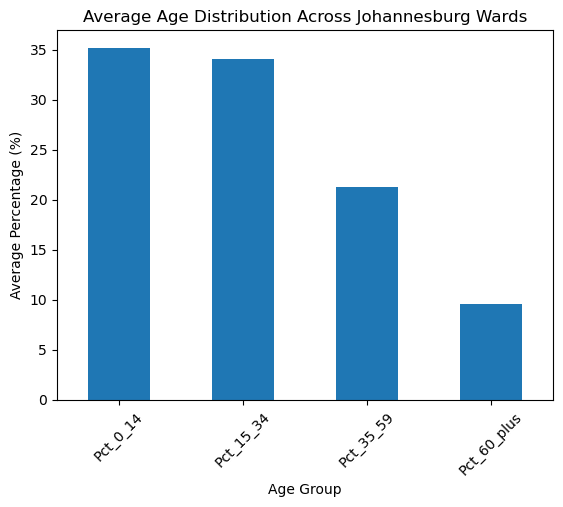

In [41]:
age_means = jhb_age[
    ["Pct_0_14", "Pct_15_34", "Pct_35_59", "Pct_60_plus"]
].mean()

age_means.plot(kind="bar")

plt.title("Average Age Distribution Across Johannesburg Wards")
plt.xlabel("Age Group")
plt.ylabel("Average Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [42]:
sex_file = [file for file in excel_files if "Sex" in file][0]

sex_file

'ward_data/Ward Product_Locked spreadsheets/PP_Sex_27-10-2025.xlsx'

In [43]:
pd.ExcelFile(sex_file).sheet_names

['Wards_Sex', 'Munic_Total_Sex']

In [45]:
pd.ExcelFile(sex_file).sheet_names

['Wards_Sex', 'Munic_Total_Sex']

In [46]:
sex_df = pd.read_excel(sex_file, sheet_name=0)

sex_df.head(10)

,WARD_CODE,Male,Female,Total
0,19100001,13064.256842,14691.477969,27755.734811
1,19100002,17134.341705,18674.050988,35808.392693
2,19100003,13250.509612,14403.054916,27653.564529
3,19100004,16253.568171,16530.224807,32783.792978
4,19100005,19212.354124,20433.030760,39645.384884
5,19100006,34233.771073,34497.501181,68731.272254
6,19100007,19734.983588,21429.970377,41164.953965
7,19100008,21450.840361,22680.643849,44131.484210
8,19100009,14711.883139,16401.746037,31113.629176
9,19100010,13928.541562,14148.423539,28076.965101


In [47]:
sex_df.columns

Index(['WARD_CODE', 'Male', 'Female', 'Total'], dtype='str')

In [48]:
sex_df = pd.read_excel(sex_file, sheet_name="Wards_Sex")

sex_df.head(10)

,WARD_CODE,Male,Female,Total
0,19100001,13064.256842,14691.477969,27755.734811
1,19100002,17134.341705,18674.050988,35808.392693
2,19100003,13250.509612,14403.054916,27653.564529
3,19100004,16253.568171,16530.224807,32783.792978
4,19100005,19212.354124,20433.030760,39645.384884
5,19100006,34233.771073,34497.501181,68731.272254
6,19100007,19734.983588,21429.970377,41164.953965
7,19100008,21450.840361,22680.643849,44131.484210
8,19100009,14711.883139,16401.746037,31113.629176
9,19100010,13928.541562,14148.423539,28076.965101


In [49]:
sex_df.shape

(4469, 4)

In [50]:
sex_df.isnull().sum()

WARD_CODE    0
Male         0
Female       0
Total        0
dtype: int64

In [51]:
sex_df["WARD_CODE"].duplicated().sum()

np.int64(0)

In [52]:
sex_df = sex_df.rename(columns={"WARD_CODE": "Ward_Code"})

sex_df["Ward_Code"] = sex_df["Ward_Code"].astype(str)

sex_df = sex_df[sex_df["Ward_Code"] != "Total"].copy()

sex_df["Municipality_Code"] = sex_df["Ward_Code"].str[:3]

sex_df.head()

,Ward_Code,Male,Female,Total,Municipality_Code
0,19100001,13064.256842,14691.477969,27755.734811,191
1,19100002,17134.341705,18674.050988,35808.392693,191
2,19100003,13250.509612,14403.054916,27653.564529,191
3,19100004,16253.568171,16530.224807,32783.792978,191
4,19100005,19212.354124,20433.030760,39645.384884,191


In [53]:
jhb_sex = sex_df[
    sex_df["Municipality_Code"] == "215"
].copy()

print("Number of Johannesburg wards:", jhb_sex["Ward_Code"].nunique())

jhb_sex.head(10)

Number of Johannesburg wards: 147


,Ward_Code,Male,Female,Total,Municipality_Code
803,21503001,4745.640306,4960.073279,9705.713585,215
804,21503002,5222.746742,5380.408784,10603.155527,215
805,21503003,5721.976067,5958.485919,11680.461986,215
806,21503004,6522.240385,7470.037703,13992.278088,215
807,21503005,5300.622979,5594.018330,10894.641310,215
808,21503006,6889.169819,7732.027179,14621.196998,215
809,21503007,5676.639906,6379.703204,12056.343110,215
810,21503008,4545.477061,5037.099761,9582.576822,215
811,21503009,5349.317000,5918.440773,11267.757773,215
812,21503010,5162.795380,5791.478409,10954.273789,215


In [54]:
jhb_sex["Pct_Male"] = (
    jhb_sex["Male"] / jhb_sex["Total"]
) * 100

jhb_sex["Pct_Female"] = (
    jhb_sex["Female"] / jhb_sex["Total"]
) * 100

jhb_sex[
    ["Ward_Code", "Male", "Female", "Total",
     "Pct_Male", "Pct_Female"]
].head(10)

,Ward_Code,Male,Female,Total,Pct_Male,Pct_Female
803,21503001,4745.640306,4960.073279,9705.713585,48.895326,51.104674
804,21503002,5222.746742,5380.408784,10603.155527,49.256532,50.743468
805,21503003,5721.976067,5958.485919,11680.461986,48.987583,51.012417
806,21503004,6522.240385,7470.037703,13992.278088,46.613142,53.386858
807,21503005,5300.622979,5594.018330,10894.641310,48.653488,51.346512
808,21503006,6889.169819,7732.027179,14621.196998,47.117687,52.882313
809,21503007,5676.639906,6379.703204,12056.343110,47.084260,52.915740
810,21503008,4545.477061,5037.099761,9582.576822,47.434810,52.565190
811,21503009,5349.317000,5918.440773,11267.757773,47.474547,52.525453
812,21503010,5162.795380,5791.478409,10954.273789,47.130421,52.869579


In [55]:
jhb_sex["Sex_Percentage_Total"] = (
    jhb_sex["Pct_Male"] + jhb_sex["Pct_Female"]
)

jhb_sex[
    ["Ward_Code", "Sex_Percentage_Total"]
].head(10)

,Ward_Code,Sex_Percentage_Total
803,21503001,100.0
804,21503002,100.0
805,21503003,100.0
806,21503004,100.0
807,21503005,100.0
808,21503006,100.0
809,21503007,100.0
810,21503008,100.0
811,21503009,100.0
812,21503010,100.0


In [56]:
jhb_sex[
    ["Male", "Female", "Total", "Pct_Male", "Pct_Female"]
].describe()

,Male,Female,Total,Pct_Male,Pct_Female
count,147.000000,147.000000,147.000000,147.000000,147.000000
mean,4814.950626,5400.710151,10215.660777,47.175694,52.824306
std,1575.447666,1782.110488,3343.689221,1.417468,1.417468
min,37.634999,35.559192,73.194191,42.925106,48.581987
25%,3931.587953,4407.180461,8274.810871,46.450450,52.015719
50%,4699.971666,5308.562207,9922.863188,47.188999,52.811001
75%,5570.868019,6375.646307,11907.841997,47.984281,53.549550
max,12033.857748,13860.845657,25894.703405,51.418013,57.074894


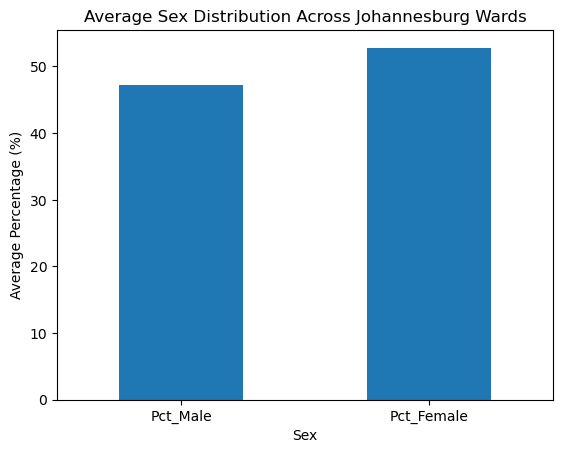

In [57]:
sex_means = jhb_sex[
    ["Pct_Male", "Pct_Female"]
].mean()

sex_means.plot(kind="bar")

plt.title("Average Sex Distribution Across Johannesburg Wards")
plt.xlabel("Sex")
plt.ylabel("Average Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [58]:
pop_file = [file for file in excel_files if "Population Group" in file][0]

pop_file

'ward_data/Ward Product_Locked spreadsheets/PP_Population Group_27-10-2025.xlsx'

In [59]:
pd.ExcelFile(pop_file).sheet_names

['Wards', 'Prov_Munic']

In [60]:
pop_df = pd.read_excel(pop_file, sheet_name=0)

pop_df.head(10)

,Ward_Code,Black African,Coloured,Indian/Asian,White,Other,Total
0,19100001,1397.159282,4030.389019,2591.734981,19132.407775,604.043754,27755.734811
1,19100002,4117.202067,11317.277440,1387.653977,17916.317711,1069.941498,35808.392693
2,19100003,2222.659174,5835.356993,511.707429,18412.511136,671.329797,27653.564529
3,19100004,17234.499447,4244.382291,1306.205198,9518.805089,479.900953,32783.792978
4,19100005,3603.590223,7426.404674,2130.491873,25738.503010,746.395104,39645.384884
5,19100006,58388.296301,7743.158580,47.968244,336.303966,2215.545164,68731.272254
6,19100007,4146.014447,30609.548223,277.382153,5746.378886,385.630256,41164.953965
7,19100008,4404.828902,8734.328482,732.295611,29467.838482,792.192733,44131.484210
8,19100009,3056.395960,25873.308062,229.227827,1089.845575,864.851752,31113.629176
9,19100010,4292.987216,19360.467230,544.223329,2684.730169,1194.557157,28076.965101


In [61]:
pop_df.columns

Index(['Ward_Code', 'Black African', 'Coloured', 'Indian/Asian', 'White',
       'Other', 'Total'],
      dtype='str')

In [62]:
pop_df = pd.read_excel(pop_file, sheet_name="Wards")

pop_df.head(10)

,Ward_Code,Black African,Coloured,Indian/Asian,White,Other,Total
0,19100001,1397.159282,4030.389019,2591.734981,19132.407775,604.043754,27755.734811
1,19100002,4117.202067,11317.277440,1387.653977,17916.317711,1069.941498,35808.392693
2,19100003,2222.659174,5835.356993,511.707429,18412.511136,671.329797,27653.564529
3,19100004,17234.499447,4244.382291,1306.205198,9518.805089,479.900953,32783.792978
4,19100005,3603.590223,7426.404674,2130.491873,25738.503010,746.395104,39645.384884
5,19100006,58388.296301,7743.158580,47.968244,336.303966,2215.545164,68731.272254
6,19100007,4146.014447,30609.548223,277.382153,5746.378886,385.630256,41164.953965
7,19100008,4404.828902,8734.328482,732.295611,29467.838482,792.192733,44131.484210
8,19100009,3056.395960,25873.308062,229.227827,1089.845575,864.851752,31113.629176
9,19100010,4292.987216,19360.467230,544.223329,2684.730169,1194.557157,28076.965101


In [63]:
pop_df.shape

(4469, 7)

In [64]:
pop_df.isnull().sum()

Ward_Code        0
Black African    0
Coloured         0
Indian/Asian     0
White            0
Other            0
Total            0
dtype: int64

In [65]:
pop_df["Ward_Code"].duplicated().sum()

np.int64(0)

In [66]:
pop_df["Ward_Code"] = pop_df["Ward_Code"].astype(str)

pop_df = pop_df[pop_df["Ward_Code"] != "Total"].copy()

pop_df["Municipality_Code"] = pop_df["Ward_Code"].str[:3]

pop_df.head()

,Ward_Code,Black African,Coloured,Indian/Asian,White,Other,Total,Municipality_Code
0,19100001,1397.159282,4030.389019,2591.734981,19132.407775,604.043754,27755.734811,191
1,19100002,4117.202067,11317.277440,1387.653977,17916.317711,1069.941498,35808.392693,191
2,19100003,2222.659174,5835.356993,511.707429,18412.511136,671.329797,27653.564529,191
3,19100004,17234.499447,4244.382291,1306.205198,9518.805089,479.900953,32783.792978,191
4,19100005,3603.590223,7426.404674,2130.491873,25738.503010,746.395104,39645.384884,191


In [67]:
jhb_pop = pop_df[
    pop_df["Municipality_Code"] == "215"
].copy()

print("Number of Johannesburg wards:", jhb_pop["Ward_Code"].nunique())

jhb_pop.head(10)

Number of Johannesburg wards: 147


,Ward_Code,Black African,Coloured,Indian/Asian,White,Other,Total,Municipality_Code
803,21503001,9661.340855,25.494577,15.790627,3.087525,0.000000,9705.713585,215
804,21503002,10549.820426,17.586966,24.731771,11.016365,0.000000,10603.155527,215
805,21503003,11661.951827,9.636068,1.265379,2.783834,4.824878,11680.461986,215
806,21503004,13952.230078,12.785481,5.989027,1.973992,19.299511,13992.278088,215
807,21503005,10839.896650,12.011631,17.764619,5.668899,19.299511,10894.641310,215
808,21503006,14472.085972,45.809165,27.819296,6.934278,68.548288,14621.196998,215
809,21503007,12010.863508,15.939390,11.117595,8.772861,9.649755,12056.343110,215
810,21503008,9537.796947,10.654157,10.257137,6.393948,17.474633,9582.576822,215
811,21503009,11218.381718,25.166873,11.623747,7.760558,4.824878,11267.757773,215
812,21503010,10921.068794,13.584051,2.986295,11.809771,4.824878,10954.273789,215


In [68]:
jhb_pop["Pct_Black_African"] = (
    jhb_pop["Black African"] / jhb_pop["Total"]
) * 100

jhb_pop["Pct_Coloured"] = (
    jhb_pop["Coloured"] / jhb_pop["Total"]
) * 100

jhb_pop["Pct_Indian_Asian"] = (
    jhb_pop["Indian/Asian"] / jhb_pop["Total"]
) * 100

jhb_pop["Pct_White"] = (
    jhb_pop["White"] / jhb_pop["Total"]
) * 100

jhb_pop["Pct_Other"] = (
    jhb_pop["Other"] / jhb_pop["Total"]
) * 100

In [69]:
jhb_pop[
    [
        "Ward_Code",
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White",
        "Pct_Other"
    ]
].head(10)

,Ward_Code,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White,Pct_Other
803,21503001,99.542818,0.262676,0.162694,0.031811,0.000000
804,21503002,99.496988,0.165865,0.233249,0.103897,0.000000
805,21503003,99.841529,0.082497,0.010833,0.023833,0.041307
806,21503004,99.713785,0.091375,0.042802,0.014108,0.137930
807,21503005,99.497508,0.110253,0.163058,0.052034,0.177147
808,21503006,98.980172,0.313307,0.190267,0.047426,0.468828
809,21503007,99.622774,0.132208,0.092214,0.072766,0.080039
810,21503008,99.532695,0.111183,0.107039,0.066725,0.182358
811,21503009,99.561793,0.223353,0.103159,0.068874,0.042820
812,21503010,99.696876,0.124007,0.027261,0.107810,0.044046


In [70]:
jhb_pop["Population_Percentage_Total"] = (
    jhb_pop["Pct_Black_African"] +
    jhb_pop["Pct_Coloured"] +
    jhb_pop["Pct_Indian_Asian"] +
    jhb_pop["Pct_White"] +
    jhb_pop["Pct_Other"]
)

jhb_pop[
    ["Ward_Code", "Population_Percentage_Total"]
].head(10)

,Ward_Code,Population_Percentage_Total
803,21503001,100.0
804,21503002,100.0
805,21503003,100.0
806,21503004,100.0
807,21503005,100.0
808,21503006,100.0
809,21503007,100.0
810,21503008,100.0
811,21503009,100.0
812,21503010,100.0


In [71]:
jhb_pop[
    [
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White",
        "Pct_Other"
    ]
].describe()

,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White,Pct_Other
count,147.000000,147.000000,147.000000,147.000000,147.000000
mean,98.386601,0.520789,0.266174,0.370636,0.455801
std,3.697596,1.001046,0.943140,1.499695,2.135120
min,72.661035,0.014073,0.000000,0.014108,0.000000
25%,98.943350,0.133874,0.070674,0.045558,0.029075
50%,99.400566,0.223353,0.124681,0.088590,0.102123
75%,99.577644,0.406233,0.188913,0.163708,0.269537
max,99.933989,7.877912,11.155588,15.673240,25.037091


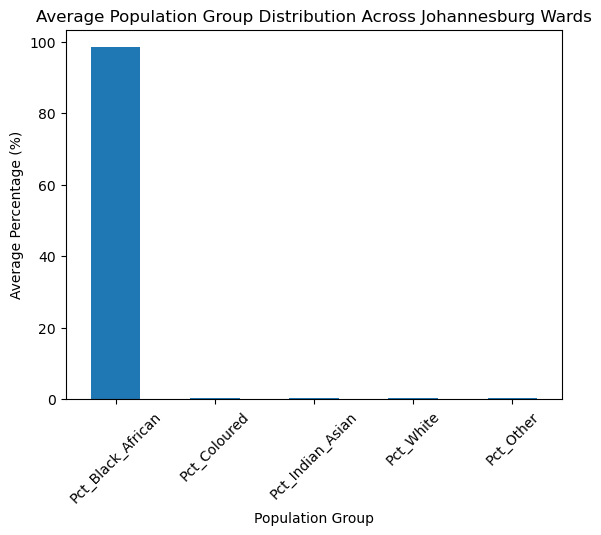

In [72]:
population_means = jhb_pop[
    [
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White",
        "Pct_Other"
    ]
].mean()

population_means.plot(kind="bar")

plt.title("Average Population Group Distribution Across Johannesburg Wards")
plt.xlabel("Population Group")
plt.ylabel("Average Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [73]:
jhb_data = jhb_age.merge(
    jhb_sex[
        ["Ward_Code", "Pct_Male", "Pct_Female"]
    ],
    on="Ward_Code",
    how="inner"
)

jhb_data.shape

(147, 33)

In [74]:
jhb_data = jhb_data.merge(
    jhb_pop[
        [
            "Ward_Code",
            "Pct_Black_African",
            "Pct_Coloured",
            "Pct_Indian_Asian",
            "Pct_White",
            "Pct_Other"
        ]
    ],
    on="Ward_Code",
    how="inner"
)

jhb_data.shape

(147, 38)

In [75]:
jhb_data[
    [
        "Ward_Code",
        "Total",
        "Pct_0_14",
        "Pct_15_34",
        "Pct_35_59",
        "Pct_60_plus",
        "Pct_Male",
        "Pct_Female",
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White",
        "Pct_Other"
    ]
].head(10)

,Ward_Code,Total,Pct_0_14,Pct_15_34,Pct_35_59,Pct_60_plus,Pct_Male,Pct_Female,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White,Pct_Other
0,21503001,9705.713585,42.366309,29.556355,18.122883,9.954452,48.895326,51.104674,99.542818,0.262676,0.162694,0.031811,0.000000
1,21503002,10603.155527,39.564502,33.523724,18.028036,8.883739,49.256532,50.743468,99.496988,0.165865,0.233249,0.103897,0.000000
2,21503003,11680.461986,39.140560,32.030025,19.179001,9.650413,48.987583,51.012417,99.841529,0.082497,0.010833,0.023833,0.041307
3,21503004,13992.278088,42.637291,32.392093,17.050331,7.920286,46.613142,53.386858,99.713785,0.091375,0.042802,0.014108,0.137930
4,21503005,10894.641310,38.267927,34.573633,19.395169,7.763272,48.653488,51.346512,99.497508,0.110253,0.163058,0.052034,0.177147
5,21503006,14621.196998,34.474428,38.848580,21.462057,5.214935,47.117687,52.882313,98.980172,0.313307,0.190267,0.047426,0.468828
6,21503007,12056.343110,39.258837,34.412779,17.629804,8.698580,47.084260,52.915740,99.622774,0.132208,0.092214,0.072766,0.080039
7,21503008,9582.576822,38.741404,36.060130,17.644855,7.553612,47.434810,52.565190,99.532695,0.111183,0.107039,0.066725,0.182358
8,21503009,11267.757773,37.583241,33.215849,20.628721,8.572188,47.474547,52.525453,99.561793,0.223353,0.103159,0.068874,0.042820
9,21503010,10954.273789,42.063686,34.937489,15.564378,7.434447,47.130421,52.869579,99.696876,0.124007,0.027261,0.107810,0.044046


In [76]:
print("Rows:", jhb_data.shape[0])
print("Columns:", jhb_data.shape[1])
print("Unique wards:", jhb_data["Ward_Code"].nunique())
print("Missing values:", jhb_data.isnull().sum().sum())

Rows: 147
Columns: 38
Unique wards: 147
Missing values: 0


In [77]:
# Correct Johannesburg municipality/ward prefix
JHB_CODE = "798"

jhb_age = df[
    df["Ward_Code"].astype(str).str.startswith(JHB_CODE)
].copy()

jhb_sex = sex_df[
    sex_df["Ward_Code"].astype(str).str.startswith(JHB_CODE)
].copy()

jhb_pop = pop_df[
    pop_df["Ward_Code"].astype(str).str.startswith(JHB_CODE)
].copy()

print("Age wards:", jhb_age["Ward_Code"].nunique())
print("Sex wards:", jhb_sex["Ward_Code"].nunique())
print("Population Group wards:", jhb_pop["Ward_Code"].nunique())

Age wards: 135
Sex wards: 135
Population Group wards: 135


In [78]:
jhb_age["Age_0_14"] = (
    jhb_age["0-4"] +
    jhb_age["5-9"] +
    jhb_age["10-14"]
)

jhb_age["Age_15_34"] = (
    jhb_age["15-19"] +
    jhb_age["20-24"] +
    jhb_age["25-29"] +
    jhb_age["30-34"]
)

jhb_age["Age_35_59"] = (
    jhb_age["35-39"] +
    jhb_age["40-44"] +
    jhb_age["45-49"] +
    jhb_age["50-54"] +
    jhb_age["55-59"]
)

jhb_age["Age_60_plus"] = (
    jhb_age["60-64"] +
    jhb_age["65-69"] +
    jhb_age["70-74"] +
    jhb_age["75-79"] +
    jhb_age["80-84"] +
    jhb_age["85+"]
)

jhb_age["Pct_0_14"] = jhb_age["Age_0_14"] / jhb_age["Total"] * 100
jhb_age["Pct_15_34"] = jhb_age["Age_15_34"] / jhb_age["Total"] * 100
jhb_age["Pct_35_59"] = jhb_age["Age_35_59"] / jhb_age["Total"] * 100
jhb_age["Pct_60_plus"] = jhb_age["Age_60_plus"] / jhb_age["Total"] * 100

In [79]:
jhb_sex["Pct_Male"] = jhb_sex["Male"] / jhb_sex["Total"] * 100
jhb_sex["Pct_Female"] = jhb_sex["Female"] / jhb_sex["Total"] * 100

In [80]:
jhb_pop["Pct_Black_African"] = (
    jhb_pop["Black African"] / jhb_pop["Total"] * 100
)

jhb_pop["Pct_Coloured"] = (
    jhb_pop["Coloured"] / jhb_pop["Total"] * 100
)

jhb_pop["Pct_Indian_Asian"] = (
    jhb_pop["Indian/Asian"] / jhb_pop["Total"] * 100
)

jhb_pop["Pct_White"] = (
    jhb_pop["White"] / jhb_pop["Total"] * 100
)

jhb_pop["Pct_Other"] = (
    jhb_pop["Other"] / jhb_pop["Total"] * 100
)

In [81]:
jhb_data = jhb_age.merge(
    jhb_sex[
        ["Ward_Code", "Pct_Male", "Pct_Female"]
    ],
    on="Ward_Code",
    how="inner"
)

jhb_data = jhb_data.merge(
    jhb_pop[
        [
            "Ward_Code",
            "Pct_Black_African",
            "Pct_Coloured",
            "Pct_Indian_Asian",
            "Pct_White",
            "Pct_Other"
        ]
    ],
    on="Ward_Code",
    how="inner"
)

print("Rows:", jhb_data.shape[0])
print("Unique wards:", jhb_data["Ward_Code"].nunique())
print("Missing values:", jhb_data.isnull().sum().sum())

Rows: 135
Unique wards: 135
Missing values: 0


In [82]:
election_2021 = pd.DataFrame({
    "Party": [
        "ANC",
        "DA",
        "ActionSA",
        "EFF",
        "Patriotic Alliance",
        "VF Plus"
    ],
    "Votes_2021": [
        620289,
        482653,
        296345,
        196163,
        54176,
        24671
    ],
    "Vote_Share_2021": [
        33.60,
        26.14,
        16.05,
        10.63,
        2.93,
        1.34
    ]
})

election_2021

,Party,Votes_2021,Vote_Share_2021
0,ANC,620289,33.60
1,DA,482653,26.14
2,ActionSA,296345,16.05
3,EFF,196163,10.63
4,Patriotic Alliance,54176,2.93
5,VF Plus,24671,1.34


In [83]:
election_2021 = election_2021.sort_values(
    "Votes_2021",
    ascending=False
).reset_index(drop=True)

election_2021

,Party,Votes_2021,Vote_Share_2021
0,ANC,620289,33.60
1,DA,482653,26.14
2,ActionSA,296345,16.05
3,EFF,196163,10.63
4,Patriotic Alliance,54176,2.93
5,VF Plus,24671,1.34


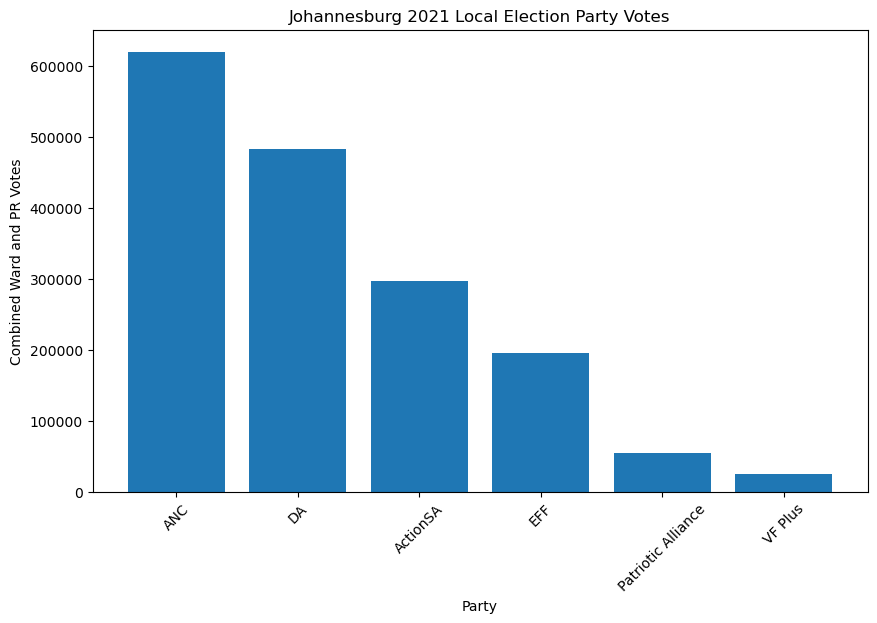

In [84]:
plt.figure(figsize=(10, 6))

plt.bar(
    election_2021["Party"],
    election_2021["Votes_2021"]
)

plt.title("Johannesburg 2021 Local Election Party Votes")
plt.xlabel("Party")
plt.ylabel("Combined Ward and PR Votes")
plt.xticks(rotation=45)
plt.show()

In [85]:
election_metadata = pd.DataFrame({
    "Variable": [
        "Election Year",
        "Municipality",
        "Municipality Code",
        "Number of Wards",
        "Total Valid Ballots",
        "Total Spoilt Ballots",
        "Combined Ballots Cast"
    ],
    "Value": [
        2021,
        "City of Johannesburg",
        "JHB / 798 ward geography",
        135,
        1846189,
        23407,
        1869596
    ]
})

election_metadata

,Variable,Value
0,Election Year,2021
1,Municipality,City of Johannesburg
2,Municipality Code,JHB / 798 ward geography
3,Number of Wards,135
4,Total Valid Ballots,1846189
5,Total Spoilt Ballots,23407
6,Combined Ballots Cast,1869596


In [86]:
historical_turnout = pd.DataFrame({
    "Year": [2021],
    "Municipality": ["City of Johannesburg"],
    "Voter_Turnout_Count": [947305]
})

historical_turnout

,Year,Municipality,Voter_Turnout_Count
0,2021,City of Johannesburg,947305


In [87]:
features = [
    "Pct_15_34",
    "Pct_35_59",
    "Pct_60_plus",
    "Pct_Male",
    "Pct_Female",
    "Pct_Black_African",
    "Pct_Coloured",
    "Pct_Indian_Asian",
    "Pct_White",
    "Pct_Other"
]

X = jhb_data[features]

X.head()

,Pct_15_34,Pct_35_59,Pct_60_plus,Pct_Male,Pct_Female,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White,Pct_Other
0,37.990506,28.992864,6.601173,50.340190,49.659810,99.342602,0.389517,0.071732,0.150925,0.045224
1,36.426746,29.304503,7.558374,48.732509,51.267491,99.456205,0.330069,0.032958,0.115839,0.064930
2,37.530076,27.421918,7.690111,49.350148,50.649852,99.301228,0.415552,0.114655,0.122546,0.046019
3,36.990135,27.694371,7.673070,49.460271,50.539729,99.412124,0.390966,0.077255,0.072527,0.047128
4,36.571317,28.500882,5.393800,50.121509,49.878491,98.980499,0.539456,0.121852,0.124557,0.233636


In [88]:
X.describe()

,Pct_15_34,Pct_35_59,Pct_60_plus,Pct_Male,Pct_Female,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White,Pct_Other
count,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000
mean,36.657018,33.125237,9.746611,50.157008,49.842992,76.742040,5.090244,4.585587,12.962198,0.619931
std,6.738893,3.498076,5.823569,2.814207,2.814207,29.553785,12.645618,9.032408,21.807054,1.698563
min,20.873891,21.713337,0.779387,39.071033,35.692987,5.506672,0.187080,0.032958,0.059103,0.006649
25%,34.236421,30.752864,5.136775,48.711363,49.130128,58.288518,0.427034,0.116589,0.132245,0.064810
50%,36.711292,32.716423,9.062001,49.950157,50.049843,95.593545,1.013203,0.340233,0.236549,0.125630
75%,39.693062,35.357727,12.416124,50.869872,51.288637,99.236156,3.440087,6.280699,14.259830,0.599472
max,56.320250,42.990755,31.547840,64.307013,60.928967,99.523397,92.101002,70.976437,76.563557,13.443877


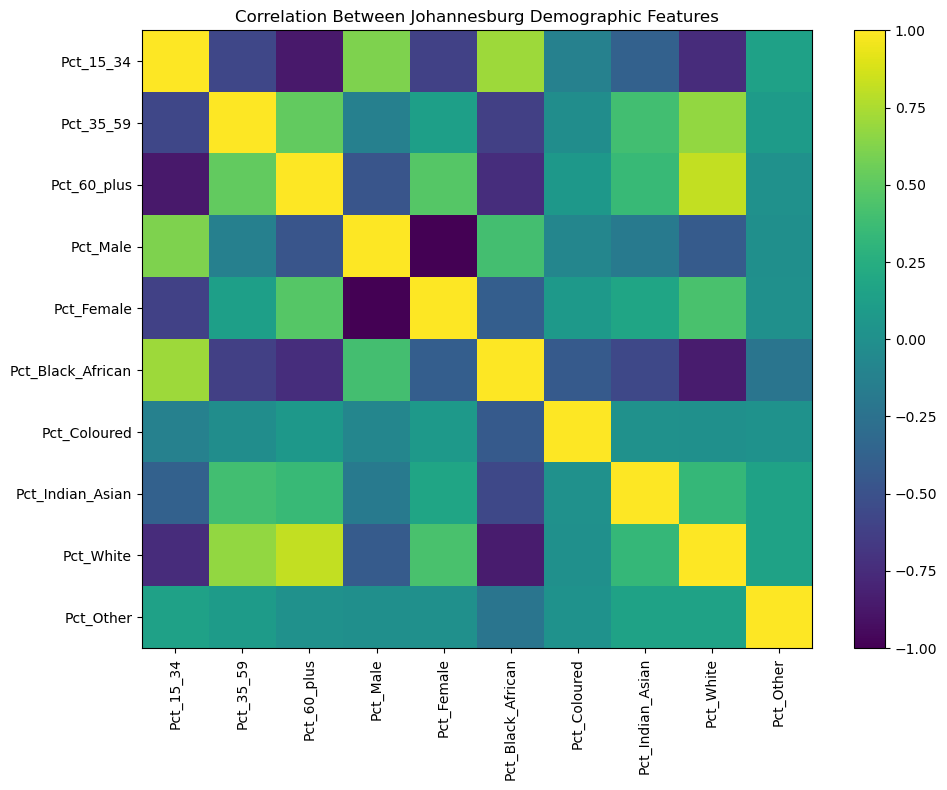

In [89]:
plt.figure(figsize=(10, 8))

correlation = X.corr()

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(features)),
    features,
    rotation=90
)

plt.yticks(
    range(len(features)),
    features
)

plt.title("Correlation Between Johannesburg Demographic Features")
plt.tight_layout()
plt.show()

In [90]:
young_ward = jhb_data.loc[
    jhb_data["Pct_15_34"].idxmax()
]

older_ward = jhb_data.loc[
    jhb_data["Pct_60_plus"].idxmax()
]

largest_ward = jhb_data.loc[
    jhb_data["Total"].idxmax()
]

selected_wards = pd.DataFrame([
    young_ward,
    older_ward,
    largest_ward
])

selected_wards[
    [
        "Ward_Code",
        "Total",
        "Pct_15_34",
        "Pct_60_plus",
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White"
    ]
]

,Ward_Code,Total,Pct_15_34,Pct_60_plus,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White
59,79800060,19908.154882,56.320250,2.063155,79.473788,1.149273,4.948488,1.598219
82,79800083,17608.412761,20.873891,31.547840,15.574412,4.084165,2.988202,76.563557
99,79800100,103284.591330,42.869998,1.661124,98.812187,0.595626,0.283003,0.191321


In [91]:
party_baseline = pd.DataFrame({
    "Party": [
        "ANC",
        "DA",
        "ActionSA",
        "EFF",
        "Patriotic Alliance",
        "VF Plus"
    ],
    "Baseline_2021_Share": [
        33.60,
        26.14,
        16.05,
        10.63,
        2.93,
        1.34
    ]
})

party_baseline

,Party,Baseline_2021_Share
0,ANC,33.60
1,DA,26.14
2,ActionSA,16.05
3,EFF,10.63
4,Patriotic Alliance,2.93
5,VF Plus,1.34


In [92]:
baseline_total = party_baseline["Baseline_2021_Share"].sum()

print("Selected parties represent:", round(baseline_total, 2), "%")

Selected parties represent: 90.69 %


In [93]:
other_share = 100 - baseline_total

print("Other parties:", round(other_share, 2), "%")

Other parties: 9.31 %


In [94]:
scenario_change = {
    "ANC": -3.0,
    "DA": 1.5,
    "ActionSA": 1.0,
    "EFF": 0.5,
    "Patriotic Alliance": 0.3,
    "VF Plus": 0.0
}

party_baseline["Scenario_Change"] = (
    party_baseline["Party"].map(scenario_change)
)

party_baseline

,Party,Baseline_2021_Share,Scenario_Change
0,ANC,33.60,-3.0
1,DA,26.14,1.5
2,ActionSA,16.05,1.0
3,EFF,10.63,0.5
4,Patriotic Alliance,2.93,0.3
5,VF Plus,1.34,0.0


In [95]:
party_baseline["Projected_2026_Share"] = (
    party_baseline["Baseline_2021_Share"] +
    party_baseline["Scenario_Change"]
)

party_baseline[
    [
        "Party",
        "Baseline_2021_Share",
        "Scenario_Change",
        "Projected_2026_Share"
    ]
]

,Party,Baseline_2021_Share,Scenario_Change,Projected_2026_Share
0,ANC,33.60,-3.0,30.60
1,DA,26.14,1.5,27.64
2,ActionSA,16.05,1.0,17.05
3,EFF,10.63,0.5,11.13
4,Patriotic Alliance,2.93,0.3,3.23
5,VF Plus,1.34,0.0,1.34


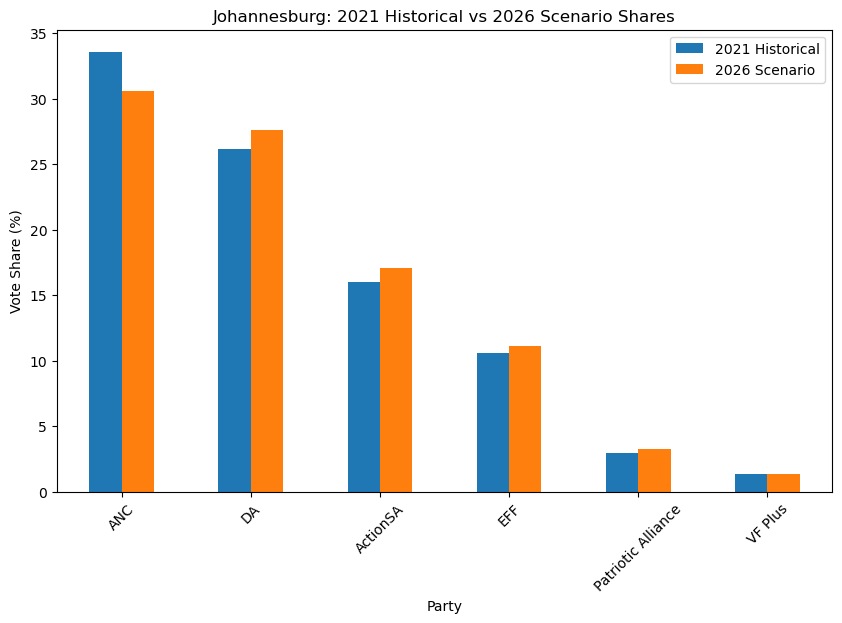

In [96]:
comparison = party_baseline.set_index("Party")[
    ["Baseline_2021_Share", "Projected_2026_Share"]
]

comparison.plot(kind="bar", figsize=(10, 6))

plt.title("Johannesburg: 2021 Historical vs 2026 Scenario Shares")
plt.xlabel("Party")
plt.ylabel("Vote Share (%)")
plt.xticks(rotation=45)
plt.legend(["2021 Historical", "2026 Scenario"])
plt.show()

In [97]:
largest_projected_party = party_baseline.loc[
    party_baseline["Projected_2026_Share"].idxmax()
]

print(
    "Largest projected party:",
    largest_projected_party["Party"]
)

print(
    "Projected share:",
    round(largest_projected_party["Projected_2026_Share"], 2),
    "%"
)

Largest projected party: ANC
Projected share: 30.6 %


In [98]:
largest_share = party_baseline["Projected_2026_Share"].max()

if largest_share > 50:
    print("Model output: A party exceeds the 50% vote-share threshold.")
else:
    print("Model output: No modelled party exceeds the 50% vote-share threshold.")
    print("The projected result is therefore coalition-relevant.")

Model output: No modelled party exceeds the 50% vote-share threshold.
The projected result is therefore coalition-relevant.


In [99]:
historical_voters = 947305

population_2022 = jhb_data["Total"].sum()

print("Johannesburg population estimate:", round(population_2022))
print("Historical voter turnout count:", historical_voters)

Johannesburg population estimate: 4803262
Historical voter turnout count: 947305


In [100]:
turnout_growth_assumption = 1.05

projected_voters_2026 = round(
    historical_voters * turnout_growth_assumption
)

print("Projected voters in 2026:", projected_voters_2026)

Projected voters in 2026: 994670


In [101]:
party_baseline["Projected_2026_Votes"] = (
    projected_voters_2026 *
    party_baseline["Projected_2026_Share"] / 100
).round().astype(int)

party_baseline[
    ["Party", "Projected_2026_Share", "Projected_2026_Votes"]
]

,Party,Projected_2026_Share,Projected_2026_Votes
0,ANC,30.60,304369
1,DA,27.64,274927
2,ActionSA,17.05,169591
3,EFF,11.13,110707
4,Patriotic Alliance,3.23,32128
5,VF Plus,1.34,13329


In [102]:
largest_party = party_baseline.loc[
    party_baseline["Projected_2026_Votes"].idxmax()
]

print("Largest projected party:", largest_party["Party"])
print("Projected votes:", largest_party["Projected_2026_Votes"])
print("Projected vote share:", largest_party["Projected_2026_Share"], "%")

Largest projected party: ANC
Projected votes: 304369
Projected vote share: 30.6 %


In [103]:
if largest_party["Projected_2026_Share"] > 50:
    print("A modelled party exceeds the 50% threshold.")
else:
    print("No modelled party exceeds the 50% threshold.")
    print("Model output indicates a coalition-relevant result.")

No modelled party exceeds the 50% threshold.
Model output indicates a coalition-relevant result.


In [104]:
three_wards = jhb_data[
    jhb_data["Ward_Code"].isin(
        ["79800060", "79800083", "79800100"]
    )
].copy()

three_wards[
    [
        "Ward_Code",
        "Total",
        "Pct_15_34",
        "Pct_60_plus",
        "Pct_Black_African",
        "Pct_Coloured",
        "Pct_Indian_Asian",
        "Pct_White"
    ]
]

,Ward_Code,Total,Pct_15_34,Pct_60_plus,Pct_Black_African,Pct_Coloured,Pct_Indian_Asian,Pct_White
59,79800060,19908.154882,56.320250,2.063155,79.473788,1.149273,4.948488,1.598219
82,79800083,17608.412761,20.873891,31.547840,15.574412,4.084165,2.988202,76.563557
99,79800100,103284.591330,42.869998,1.661124,98.812187,0.595626,0.283003,0.191321


In [105]:
three_wards["Estimated_20_Plus"] = (
    three_wards["Total"]
    - three_wards["Age_0_14"]
    - three_wards["15-19"]
)

three_wards[
    ["Ward_Code", "Total", "Estimated_20_Plus"]
]

,Ward_Code,Total,Estimated_20_Plus
59,79800060,19908.154882,15409.309213
82,79800083,17608.412761,14620.044704
99,79800100,103284.591330,73427.407076


In [106]:
three_wards["Projected_2026_Voters"] = (
    three_wards["Estimated_20_Plus"] * 0.50
).round().astype(int)

three_wards[
    ["Ward_Code", "Projected_2026_Voters"]
]

,Ward_Code,Projected_2026_Voters
59,79800060,7705
82,79800083,7310
99,79800100,36714


In [107]:
def project_ward(row):
    
    shares = {
        "ANC": 30.60,
        "DA": 27.64,
        "ActionSA": 17.05,
        "EFF": 11.13,
        "Patriotic Alliance": 3.23,
        "VF Plus": 1.34
    }

    # Small demographic scenario adjustments
    if row["Pct_15_34"] > 45:
        shares["ActionSA"] += 2
        shares["EFF"] += 1
        shares["ANC"] -= 2

    if row["Pct_60_plus"] > 20:
        shares["DA"] += 3
        shares["VF Plus"] += 1
        shares["ANC"] -= 2

    if row["Pct_Black_African"] > 80:
        shares["ANC"] += 3
        shares["EFF"] += 1

    if row["Pct_White"] > 50:
        shares["DA"] += 5
        shares["VF Plus"] += 2
        shares["ANC"] -= 3

    return shares

In [108]:
ward_projection_rows = []

for _, row in three_wards.iterrows():

    shares = project_ward(row)

    for party, share in shares.items():

        ward_projection_rows.append({
            "Ward_Code": row["Ward_Code"],
            "Party": party,
            "Projected_Share": share,
            "Projected_Voters": row["Projected_2026_Voters"]
        })

ward_predictions = pd.DataFrame(ward_projection_rows)

ward_predictions.head(10)

,Ward_Code,Party,Projected_Share,Projected_Voters
0,79800060,ANC,28.60,7705
1,79800060,DA,27.64,7705
2,79800060,ActionSA,19.05,7705
3,79800060,EFF,12.13,7705
4,79800060,Patriotic Alliance,3.23,7705
5,79800060,VF Plus,1.34,7705
6,79800083,ANC,25.60,7310
7,79800083,DA,35.64,7310
8,79800083,ActionSA,17.05,7310
9,79800083,EFF,11.13,7310


In [109]:
ward_predictions["Projected_Votes"] = (
    ward_predictions["Projected_Voters"]
    * ward_predictions["Projected_Share"] / 100
).round().astype(int)

ward_predictions[
    [
        "Ward_Code",
        "Party",
        "Projected_Share",
        "Projected_Votes"
    ]
]

,Ward_Code,Party,Projected_Share,Projected_Votes
0,79800060,ANC,28.60,2204
1,79800060,DA,27.64,2130
2,79800060,ActionSA,19.05,1468
3,79800060,EFF,12.13,935
4,79800060,Patriotic Alliance,3.23,249
5,79800060,VF Plus,1.34,103
6,79800083,ANC,25.60,1871
7,79800083,DA,35.64,2605
8,79800083,ActionSA,17.05,1246
9,79800083,EFF,11.13,814


In [110]:
ward_leaders = ward_predictions.loc[
    ward_predictions.groupby("Ward_Code")[
        "Projected_Votes"
    ].idxmax()
]

ward_leaders[
    [
        "Ward_Code",
        "Party",
        "Projected_Share",
        "Projected_Votes"
    ]
].reset_index(drop=True)

,Ward_Code,Party,Projected_Share,Projected_Votes
0,79800060,ANC,28.60,2204
1,79800083,DA,35.64,2605
2,79800100,ANC,33.60,12336


In [111]:
ward_results_table = ward_predictions.pivot(
    index="Ward_Code",
    columns="Party",
    values="Projected_Votes"
)

ward_results_table

Party,ANC,ActionSA,DA,EFF,Patriotic Alliance,VF Plus
Ward_Code,,,,,,
79800060,2204,1468,2130,935,249,103
79800083,1871,1246,2605,814,236,317
79800100,12336,6260,10148,4453,1186,492


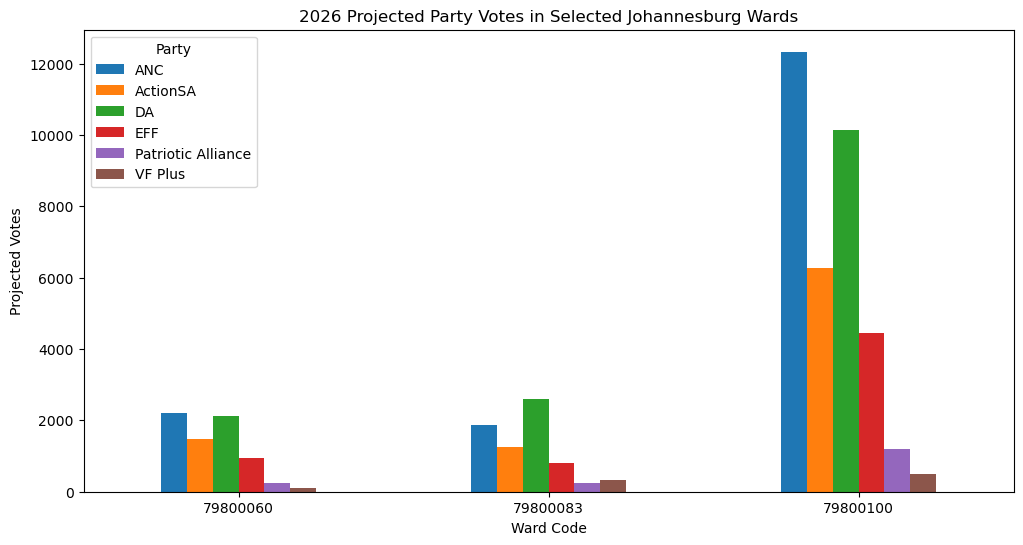

In [112]:
ward_results_table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("2026 Projected Party Votes in Selected Johannesburg Wards")
plt.xlabel("Ward Code")
plt.ylabel("Projected Votes")
plt.xticks(rotation=0)
plt.legend(title="Party")
plt.show()

In [113]:
ward_selection = pd.DataFrame({
    "Ward_Code": [
        "79800060",
        "79800083",
        "79800100"
    ],
    "Selection_Reason": [
        "Highest 15-34 age-group share",
        "Highest 60+ age-group share",
        "Largest estimated population"
    ]
})

ward_selection

,Ward_Code,Selection_Reason
0,79800060,Highest 15-34 age-group share
1,79800083,Highest 60+ age-group share
2,79800100,Largest estimated population


In [114]:
final_ward_results = ward_leaders[
    [
        "Ward_Code",
        "Party",
        "Projected_Share",
        "Projected_Votes"
    ]
].copy()

final_ward_results.columns = [
    "Ward_Code",
    "Projected_Leading_Party",
    "Projected_Vote_Share",
    "Projected_Votes"
]

final_ward_results.reset_index(drop=True)

,Ward_Code,Projected_Leading_Party,Projected_Vote_Share,Projected_Votes
0,79800060,ANC,28.60,2204
1,79800083,DA,35.64,2605
2,79800100,ANC,33.60,12336


In [115]:
final_party_results = party_baseline[
    [
        "Party",
        "Baseline_2021_Share",
        "Projected_2026_Share",
        "Projected_2026_Votes"
    ]
].copy()

final_party_results = final_party_results.sort_values(
    "Projected_2026_Votes",
    ascending=False
).reset_index(drop=True)

final_party_results

,Party,Baseline_2021_Share,Projected_2026_Share,Projected_2026_Votes
0,ANC,33.60,30.60,304369
1,DA,26.14,27.64,274927
2,ActionSA,16.05,17.05,169591
3,EFF,10.63,11.13,110707
4,Patriotic Alliance,2.93,3.23,32128
5,VF Plus,1.34,1.34,13329


In [116]:
final_party_results["Projected_Rank"] = (
    final_party_results["Projected_2026_Votes"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

final_party_results[
    [
        "Projected_Rank",
        "Party",
        "Projected_2026_Share",
        "Projected_2026_Votes"
    ]
]

,Projected_Rank,Party,Projected_2026_Share,Projected_2026_Votes
0,1,ANC,30.60,304369
1,2,DA,27.64,274927
2,3,ActionSA,17.05,169591
3,4,EFF,11.13,110707
4,5,Patriotic Alliance,3.23,32128
5,6,VF Plus,1.34,13329


In [117]:
modelled_share = final_party_results[
    "Projected_2026_Share"
].sum()

other_parties_share = 100 - modelled_share

other_parties_votes = round(
    projected_voters_2026 *
    other_parties_share / 100
)

print("Modelled parties share:", round(modelled_share, 2), "%")
print("Other parties share:", round(other_parties_share, 2), "%")
print("Projected other-party votes:", other_parties_votes)

Modelled parties share: 90.99 %
Other parties share: 9.01 %
Projected other-party votes: 89620


In [118]:
modelled_votes = final_party_results[
    "Projected_2026_Votes"
].sum()

total_check = modelled_votes + other_parties_votes

print("Relevant party votes:", modelled_votes)
print("Other party votes:", other_parties_votes)
print("Total projected voters:", total_check)
print("Expected projected voters:", projected_voters_2026)

Relevant party votes: 905051
Other party votes: 89620
Total projected voters: 994671
Expected projected voters: 994670


In [119]:
turnout_change = (
    (projected_voters_2026 - historical_voters)
    / historical_voters
) * 100

print("2021 voter turnout count:", historical_voters)
print("2026 projected voter turnout count:", projected_voters_2026)
print("Assumed change:", round(turnout_change, 2), "%")

2021 voter turnout count: 947305
2026 projected voter turnout count: 994670
Assumed change: 5.0 %


In [120]:
top_party = final_party_results.iloc[0]

print("Largest projected party:", top_party["Party"])
print(
    "Projected vote share:",
    round(top_party["Projected_2026_Share"], 2),
    "%"
)

if top_party["Projected_2026_Share"] > 50:
    coalition_status = "Projected outright vote majority"
else:
    coalition_status = "No projected outright vote majority; coalition-relevant"

print("Model output:", coalition_status)

Largest projected party: ANC
Projected vote share: 30.6 %
Model output: No projected outright vote majority; coalition-relevant


In [121]:
final_ward_results[
    [
        "Ward_Code",
        "Projected_Leading_Party",
        "Projected_Vote_Share",
        "Projected_Votes"
    ]
].reset_index(drop=True)

,Ward_Code,Projected_Leading_Party,Projected_Vote_Share,Projected_Votes
0,79800060,ANC,28.60,2204
1,79800083,DA,35.64,2605
2,79800100,ANC,33.60,12336


In [122]:
print("2026 SOUTH AFRICAN LOCAL GOVERNMENT ELECTION ANALYTICS")
print("City of Johannesburg Metropolitan Municipality")
print("-" * 60)

print(
    "Largest projected party:",
    top_party["Party"]
)

print(
    "Largest projected vote total:",
    int(top_party["Projected_2026_Votes"])
)

print(
    "Largest projected vote share:",
    round(top_party["Projected_2026_Share"], 2),
    "%"
)

print(
    "Projected participating voters:",
    projected_voters_2026
)

print(
    "Majority / coalition indicator:",
    coalition_status
)

print("\nTHREE SELECTED WARDS")

for _, row in final_ward_results.iterrows():
    print(
        row["Ward_Code"],
        "->",
        row["Projected_Leading_Party"],
        "|",
        round(row["Projected_Vote_Share"], 2),
        "%",
        "|",
        int(row["Projected_Votes"]),
        "votes"
    )

2026 SOUTH AFRICAN LOCAL GOVERNMENT ELECTION ANALYTICS
City of Johannesburg Metropolitan Municipality
------------------------------------------------------------
Largest projected party: ANC
Largest projected vote total: 304369
Largest projected vote share: 30.6 %
Projected participating voters: 994670
Majority / coalition indicator: No projected outright vote majority; coalition-relevant

THREE SELECTED WARDS
79800060 -> ANC | 28.6 % | 2204 votes
79800083 -> DA | 35.64 % | 2605 votes
79800100 -> ANC | 33.6 % | 12336 votes


In [123]:
variable_types = pd.DataFrame({
    "Category": [
        "Historical Observation",
        "Historical Observation",
        "Derived Variable",
        "Derived Variable",
        "Projection",
        "Projection",
        "Projection",
        "Projection"
    ],

    "Variable": [
        "2021 party vote shares",
        "2021 voter turnout count",
        "Ward demographic percentages",
        "Estimated population aged 20+",
        "2026 participating voters",
        "2026 party vote shares",
        "2026 party vote totals",
        "2026 ward leading party"
    ],

    "Description": [
        "Observed IEC 2021 Johannesburg election results",
        "Observed IEC 2021 Johannesburg turnout count",
        "Calculated from Stats SA ward demographic data",
        "Proxy calculated from available age groups",
        "Scenario estimate based on turnout assumption",
        "Scenario-based estimates",
        "Calculated from projected voters and projected shares",
        "Scenario-based ward projection"
    ]
})

variable_types

,Category,Variable,Description
0,Historical Observation,2021 party vote shares,Observed IEC 2021 Johannesburg election results
1,Historical Observation,2021 voter turnout count,Observed IEC 2021 Johannesburg turnout count
2,Derived Variable,Ward demographic percentages,Calculated from Stats SA ward demographic data
3,Derived Variable,Estimated population aged 20+,Proxy calculated from available age groups
4,Projection,2026 participating voters,Scenario estimate based on turnout assumption
5,Projection,2026 party vote shares,Scenario-based estimates
6,Projection,2026 party vote totals,Calculated from projected voters and projected...
7,Projection,2026 ward leading party,Scenario-based ward projection


In [124]:
limitations = [
    "The 2026 results are scenario-based projections, not known election outcomes.",
    
    "Only the supplied 2021 metro-level election results were available as the historical electoral baseline.",
    
    "Historical ward-level election results were not available for model training and back-testing.",
    
    "Demographic characteristics do not directly determine political preference.",
    
    "The 2026 turnout count uses an explicit growth assumption rather than a trained turnout forecasting model.",
    
    "A registered-voter denominator was not available, so an official turnout percentage was not estimated.",
    
    "The age 20+ population is used as a proxy because the demographic age bands do not isolate ages 18 and 19.",
    
    "Ward projections are scenario estimates based on demographic contrasts and should not be interpreted as certain outcomes.",
    
    "Coalition formation depends on council seats and political negotiations. The model only identifies whether an outright vote-share majority is projected.",
    
    "Ward boundaries and geographic comparability must be considered when comparing election years."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

1. The 2026 results are scenario-based projections, not known election outcomes.
2. Only the supplied 2021 metro-level election results were available as the historical electoral baseline.
3. Historical ward-level election results were not available for model training and back-testing.
4. Demographic characteristics do not directly determine political preference.
5. The 2026 turnout count uses an explicit growth assumption rather than a trained turnout forecasting model.
6. A registered-voter denominator was not available, so an official turnout percentage was not estimated.
7. The age 20+ population is used as a proxy because the demographic age bands do not isolate ages 18 and 19.
8. Ward projections are scenario estimates based on demographic contrasts and should not be interpreted as certain outcomes.
9. Coalition formation depends on council seats and political negotiations. The model only identifies whether an outright vote-share majority is projected.
10. Ward boundaries and geo

In [125]:
print("FINAL INTERPRETATION")
print("-" * 50)

print(
    f"The scenario model projects {top_party['Party']} "
    f"to have the largest aggregate vote total in Johannesburg "
    f"with approximately {int(top_party['Projected_2026_Votes']):,} votes "
    f"and {top_party['Projected_2026_Share']:.2f}% of the modelled vote."
)

print(
    f"The model estimates approximately "
    f"{projected_voters_2026:,} participating voters in 2026."
)

print(
    "No modelled party exceeds the 50% vote-share threshold, "
    "so the model produces a coalition-relevant result. "
    "This does not predict which parties would form a government."
)

print(
    "For the three selected wards, the projected leaders are:"
)

for _, row in final_ward_results.iterrows():
    print(
        f"{row['Ward_Code']}: "
        f"{row['Projected_Leading_Party']} "
        f"({row['Projected_Vote_Share']:.2f}%)"
    )

FINAL INTERPRETATION
--------------------------------------------------
The scenario model projects ANC to have the largest aggregate vote total in Johannesburg with approximately 304,369 votes and 30.60% of the modelled vote.
The model estimates approximately 994,670 participating voters in 2026.
No modelled party exceeds the 50% vote-share threshold, so the model produces a coalition-relevant result. This does not predict which parties would form a government.
For the three selected wards, the projected leaders are:
79800060: ANC (28.60%)
79800083: DA (35.64%)
79800100: ANC (33.60%)


In [126]:
share_check = party_baseline["Projected_2026_Share"].sum()

print("Relevant parties projected share:", round(share_check, 2), "%")
print("Other parties projected share:", round(100 - share_check, 2), "%")
print("Total:", round(share_check + (100 - share_check), 2), "%")

Relevant parties projected share: 90.99 %
Other parties projected share: 9.01 %
Total: 100.0 %


In [127]:
relevant_votes = party_baseline["Projected_2026_Votes"].sum()

all_projected_votes = (
    relevant_votes + other_parties_votes
)

difference = (
    projected_voters_2026 - all_projected_votes
)

print("Projected participating voters:", projected_voters_2026)
print("Relevant party votes:", relevant_votes)
print("Other party votes:", other_parties_votes)
print("Total allocated votes:", all_projected_votes)
print("Rounding difference:", difference)

Projected participating voters: 994670
Relevant party votes: 905051
Other party votes: 89620
Total allocated votes: 994671
Rounding difference: -1


In [128]:
evaluation_table = party_baseline[
    [
        "Party",
        "Baseline_2021_Share",
        "Projected_2026_Share"
    ]
].copy()

evaluation_table["Change_Percentage_Points"] = (
    evaluation_table["Projected_2026_Share"]
    - evaluation_table["Baseline_2021_Share"]
)

evaluation_table

,Party,Baseline_2021_Share,Projected_2026_Share,Change_Percentage_Points
0,ANC,33.60,30.60,-3.0
1,DA,26.14,27.64,1.5
2,ActionSA,16.05,17.05,1.0
3,EFF,10.63,11.13,0.5
4,Patriotic Alliance,2.93,3.23,0.3
5,VF Plus,1.34,1.34,0.0


In [129]:
evaluation_table["Absolute_Change"] = (
    evaluation_table["Change_Percentage_Points"].abs()
)

evaluation_table[
    [
        "Party",
        "Baseline_2021_Share",
        "Projected_2026_Share",
        "Change_Percentage_Points",
        "Absolute_Change"
    ]
]

,Party,Baseline_2021_Share,Projected_2026_Share,Change_Percentage_Points,Absolute_Change
0,ANC,33.60,30.60,-3.0,3.0
1,DA,26.14,27.64,1.5,1.5
2,ActionSA,16.05,17.05,1.0,1.0
3,EFF,10.63,11.13,0.5,0.5
4,Patriotic Alliance,2.93,3.23,0.3,0.3
5,VF Plus,1.34,1.34,0.0,0.0


In [130]:
mean_absolute_adjustment = (
    evaluation_table["Absolute_Change"].mean()
)

print(
    "Mean absolute scenario adjustment:",
    round(mean_absolute_adjustment, 2),
    "percentage points"
)

Mean absolute scenario adjustment: 1.05 percentage points


In [131]:
turnout_scenarios = pd.DataFrame({
    "Scenario": [
        "Lower Turnout",
        "Base Scenario",
        "Higher Turnout"
    ],
    
    "Growth_Factor": [
        0.95,
        1.05,
        1.15
    ]
})

turnout_scenarios["Projected_Voters"] = (
    historical_voters *
    turnout_scenarios["Growth_Factor"]
).round().astype(int)

turnout_scenarios

,Scenario,Growth_Factor,Projected_Voters
0,Lower Turnout,0.95,899940
1,Base Scenario,1.05,994670
2,Higher Turnout,1.15,1089401


In [132]:
sensitivity_results = []

for _, scenario in turnout_scenarios.iterrows():

    for _, party in party_baseline.iterrows():

        votes = round(
            scenario["Projected_Voters"]
            * party["Projected_2026_Share"]
            / 100
        )

        sensitivity_results.append({
            "Scenario": scenario["Scenario"],
            "Party": party["Party"],
            "Projected_Votes": votes
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,Scenario,Party,Projected_Votes
0,Lower Turnout,ANC,275382
1,Lower Turnout,DA,248743
2,Lower Turnout,ActionSA,153440
3,Lower Turnout,EFF,100163
4,Lower Turnout,Patriotic Alliance,29068
5,Lower Turnout,VF Plus,12059
6,Base Scenario,ANC,304369
7,Base Scenario,DA,274927
8,Base Scenario,ActionSA,169591
9,Base Scenario,EFF,110707


In [133]:
sensitivity_leaders = sensitivity_df.loc[
    sensitivity_df.groupby("Scenario")[
        "Projected_Votes"
    ].idxmax()
]

sensitivity_leaders[
    [
        "Scenario",
        "Party",
        "Projected_Votes"
    ]
].reset_index(drop=True)

,Scenario,Party,Projected_Votes
0,Base Scenario,ANC,304369
1,Higher Turnout,ANC,333357
2,Lower Turnout,ANC,275382


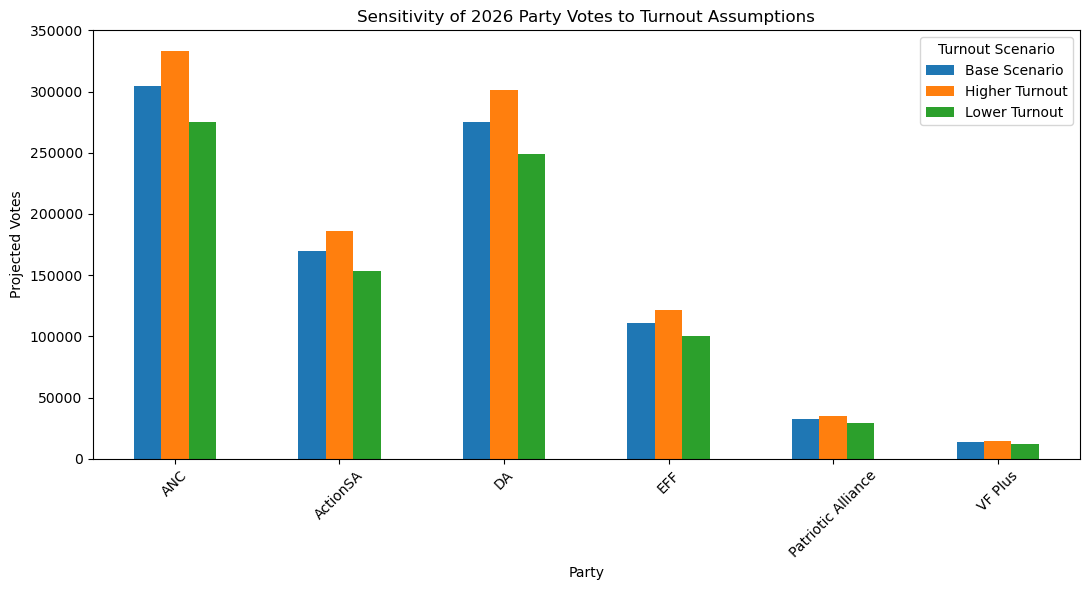

In [134]:
sensitivity_pivot = sensitivity_df.pivot(
    index="Party",
    columns="Scenario",
    values="Projected_Votes"
)

sensitivity_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Sensitivity of 2026 Party Votes to Turnout Assumptions")
plt.xlabel("Party")
plt.ylabel("Projected Votes")
plt.xticks(rotation=45)
plt.legend(title="Turnout Scenario")
plt.tight_layout()
plt.show()

In [135]:
ward_validation = (
    ward_predictions
    .groupby("Ward_Code")
    .agg(
        Total_Projected_Share=("Projected_Share", "sum"),
        Allocated_Party_Votes=("Projected_Votes", "sum"),
        Estimated_Voters=("Projected_Voters", "first")
    )
    .reset_index()
)

ward_validation["Unallocated_Share"] = (
    100 - ward_validation["Total_Projected_Share"]
)

ward_validation

,Ward_Code,Total_Projected_Share,Allocated_Party_Votes,Estimated_Voters,Unallocated_Share
0,79800060,91.99,7089,7705,8.01
1,79800083,96.99,7089,7310,3.01
2,79800100,94.99,34875,36714,5.01


In [136]:
validation_summary = pd.DataFrame({
    "Validation_Check": [
        "Metro vote shares",
        "Metro vote allocation",
        "Turnout sensitivity",
        "Ward vote shares",
        "Historical back-testing"
    ],

    "Result": [
        "Pass - relevant parties plus Other Parties account for 100%",
        "Pass - projected votes reconcile with projected participating voters subject to rounding",
        "Tested using lower, base and higher turnout scenarios",
        "Partial - unallocated share represents parties outside the six relevant parties",
        "Not possible with the supplied metro-level historical election data"
    ]
})

validation_summary

,Validation_Check,Result
0,Metro vote shares,Pass - relevant parties plus Other Parties acc...
1,Metro vote allocation,Pass - projected votes reconcile with projecte...
2,Turnout sensitivity,"Tested using lower, base and higher turnout sc..."
3,Ward vote shares,Partial - unallocated share represents parties...
4,Historical back-testing,Not possible with the supplied metro-level his...


In [137]:
print("MODEL EVALUATION")
print("-" * 60)

print(
    "The analysis uses a transparent scenario-based projection "
    "rather than a supervised machine-learning forecasting model."
)

print(
    "This approach was selected because multiple comparable "
    "historical ward-level election observations were not available "
    "in the supplied data."
)

print(
    "The model was evaluated using internal consistency checks "
    "and sensitivity analysis."
)

print(
    "Traditional prediction metrics such as accuracy, MAE, RMSE "
    "and R-squared are not reported because there are no observed "
    "2026 election outcomes against which the projections can be tested."
)

print(
    "The projections should therefore be interpreted as analytical "
    "scenario outputs rather than certain election forecasts."
)

MODEL EVALUATION
------------------------------------------------------------
The analysis uses a transparent scenario-based projection rather than a supervised machine-learning forecasting model.
This approach was selected because multiple comparable historical ward-level election observations were not available in the supplied data.
The model was evaluated using internal consistency checks and sensitivity analysis.
Traditional prediction metrics such as accuracy, MAE, RMSE and R-squared are not reported because there are no observed 2026 election outcomes against which the projections can be tested.
The projections should therefore be interpreted as analytical scenario outputs rather than certain election forecasts.


In [138]:
print("GEOGRAPHIC COMPARABILITY")
print("-" * 60)

print(
    "The demographic analysis contains 135 Johannesburg ward records "
    "identified using ward codes beginning with 798."
)

print(
    "The supplied election evidence provides a 2021 municipality-level "
    "baseline rather than a historical ward-level panel."
)

print(
    "Therefore, historical ward results from different election years "
    "were not directly merged by ward number."
)

print(
    "This avoids assuming that ward identifiers and boundaries remained "
    "geographically identical across election cycles."
)

print(
    "A stronger future analysis would use official boundary files or "
    "voting-district crosswalks to align historical election results "
    "to a common Johannesburg geography before model training."
)

GEOGRAPHIC COMPARABILITY
------------------------------------------------------------
The demographic analysis contains 135 Johannesburg ward records identified using ward codes beginning with 798.
The supplied election evidence provides a 2021 municipality-level baseline rather than a historical ward-level panel.
Therefore, historical ward results from different election years were not directly merged by ward number.
This avoids assuming that ward identifiers and boundaries remained geographically identical across election cycles.
A stronger future analysis would use official boundary files or voting-district crosswalks to align historical election results to a common Johannesburg geography before model training.


In [139]:
final_display = final_party_results[
    [
        "Projected_Rank",
        "Party",
        "Baseline_2021_Share",
        "Projected_2026_Share",
        "Projected_2026_Votes"
    ]
].sort_values("Projected_Rank")

final_display

,Projected_Rank,Party,Baseline_2021_Share,Projected_2026_Share,Projected_2026_Votes
0,1,ANC,33.60,30.60,304369
1,2,DA,26.14,27.64,274927
2,3,ActionSA,16.05,17.05,169591
3,4,EFF,10.63,11.13,110707
4,5,Patriotic Alliance,2.93,3.23,32128
5,6,VF Plus,1.34,1.34,13329


In [140]:
winner = final_party_results.loc[
    final_party_results["Projected_2026_Votes"].idxmax()
]

print("QUESTION: Which relevant party has the largest projected aggregate vote total?")
print()

print("Party:", winner["Party"])
print("Projected vote total:", f"{int(winner['Projected_2026_Votes']):,}")
print("Projected vote share:", f"{winner['Projected_2026_Share']:.2f}%")

QUESTION: Which relevant party has the largest projected aggregate vote total?

Party: ANC
Projected vote total: 304,369
Projected vote share: 30.60%


In [141]:
print("QUESTION: Is the projected result coalition-relevant?")
print()

if winner["Projected_2026_Share"] > 50:
    print("Model output: An outright vote-share majority is projected.")
else:
    print("Model output: No relevant party is projected to exceed 50%.")
    print("The result is therefore coalition-relevant.")

print()
print(
    "This does not predict which parties will form a coalition "
    "or ultimately govern Johannesburg."
)

QUESTION: Is the projected result coalition-relevant?

Model output: No relevant party is projected to exceed 50%.
The result is therefore coalition-relevant.

This does not predict which parties will form a coalition or ultimately govern Johannesburg.


In [142]:
print("QUESTION: Which party is projected to lead in each selected ward?")
print()

for _, row in final_ward_results.iterrows():

    print(
        f"Ward {row['Ward_Code']}: "
        f"{row['Projected_Leading_Party']} | "
        f"{row['Projected_Vote_Share']:.2f}% | "
        f"{int(row['Projected_Votes']):,} projected votes"
    )

QUESTION: Which party is projected to lead in each selected ward?

Ward 79800060: ANC | 28.60% | 2,204 projected votes
Ward 79800083: DA | 35.64% | 2,605 projected votes
Ward 79800100: ANC | 33.60% | 12,336 projected votes


In [143]:
print("WARD SELECTION JUSTIFICATION")
print()

print(
    "79800060 was selected because it has the highest "
    "15-34 age-group share in the Johannesburg demographic dataset."
)

print(
    "79800083 was selected because it has the highest "
    "60+ age-group share."
)

print(
    "79800100 was selected because it has the largest "
    "estimated population."
)

print()
print(
    "These wards were selected to represent contrasting demographic "
    "profiles rather than being chosen randomly."
)

WARD SELECTION JUSTIFICATION

79800060 was selected because it has the highest 15-34 age-group share in the Johannesburg demographic dataset.
79800083 was selected because it has the highest 60+ age-group share.
79800100 was selected because it has the largest estimated population.

These wards were selected to represent contrasting demographic profiles rather than being chosen randomly.


In [144]:
print("2026 PROJECTED VOTE TOTALS")
print()

for _, row in final_party_results.sort_values(
    "Projected_2026_Votes",
    ascending=False
).iterrows():

    print(
        f"{row['Party']}: "
        f"{int(row['Projected_2026_Votes']):,} votes "
        f"({row['Projected_2026_Share']:.2f}%)"
    )

2026 PROJECTED VOTE TOTALS

ANC: 304,369 votes (30.60%)
DA: 274,927 votes (27.64%)
ActionSA: 169,591 votes (17.05%)
EFF: 110,707 votes (11.13%)
Patriotic Alliance: 32,128 votes (3.23%)
VF Plus: 13,329 votes (1.34%)


In [145]:
print("2026 VOTER TURNOUT PROJECTION")
print()

print(
    "Historical 2021 participating voters:",
    f"{historical_voters:,}"
)

print(
    "Projected 2026 participating voters:",
    f"{projected_voters_2026:,}"
)

print(
    "Assumed change from 2021:",
    f"{turnout_change:.2f}%"
)

print()
print(
    "A registered-voter denominator is not available in the "
    "supplied data, therefore an official turnout percentage "
    "is not estimated."
)

2026 VOTER TURNOUT PROJECTION

Historical 2021 participating voters: 947,305
Projected 2026 participating voters: 994,670
Assumed change from 2021: 5.00%

A registered-voter denominator is not available in the supplied data, therefore an official turnout percentage is not estimated.


In [146]:
summary_table = pd.DataFrame({
    "Measure": [
        "Municipality",
        "Election",
        "Largest Projected Party",
        "Largest Projected Vote Total",
        "Largest Projected Vote Share",
        "Projected Participating Voters",
        "Majority Status",
        "Ward 79800060 Leader",
        "Ward 79800083 Leader",
        "Ward 79800100 Leader"
    ],

    "Result": [
        "City of Johannesburg",
        "2026 Local Government Election",
        winner["Party"],
        f"{int(winner['Projected_2026_Votes']):,}",
        f"{winner['Projected_2026_Share']:.2f}%",
        f"{projected_voters_2026:,}",
        coalition_status,
        final_ward_results.loc[
            final_ward_results["Ward_Code"] == "79800060",
            "Projected_Leading_Party"
        ].iloc[0],
        final_ward_results.loc[
            final_ward_results["Ward_Code"] == "79800083",
            "Projected_Leading_Party"
        ].iloc[0],
        final_ward_results.loc[
            final_ward_results["Ward_Code"] == "79800100",
            "Projected_Leading_Party"
        ].iloc[0]
    ]
})

summary_table

,Measure,Result
0,Municipality,City of Johannesburg
1,Election,2026 Local Government Election
2,Largest Projected Party,ANC
3,Largest Projected Vote Total,"304,369"
4,Largest Projected Vote Share,30.60%
5,Projected Participating Voters,"994,670"
6,Majority Status,No projected outright vote majority; coalition...
7,Ward 79800060 Leader,ANC
8,Ward 79800083 Leader,DA
9,Ward 79800100 Leader,ANC


In [147]:
print("CONCLUSION")
print("-" * 60)

print(
    "This analysis developed a scenario-based projection for the "
    "2026 Local Government Election in the City of Johannesburg."
)

print(
    f"The model output places {winner['Party']} first among the "
    f"relevant parties with approximately "
    f"{int(winner['Projected_2026_Votes']):,} projected votes "
    f"and a projected share of {winner['Projected_2026_Share']:.2f}%."
)

print(
    f"Approximately {projected_voters_2026:,} participating voters "
    f"are estimated under the base turnout scenario."
)

print(
    "No relevant party reaches the 50% vote-share threshold in the "
    "base scenario, making the result coalition-relevant. "
    "This analysis does not predict which parties would form a coalition."
)

print(
    "At ward level, the scenario projects ANC to lead in wards "
    "79800060 and 79800100, while DA leads in ward 79800083."
)

print(
    "The results should be interpreted as analytical scenario outputs "
    "rather than certain election outcomes."
)

CONCLUSION
------------------------------------------------------------
This analysis developed a scenario-based projection for the 2026 Local Government Election in the City of Johannesburg.
The model output places ANC first among the relevant parties with approximately 304,369 projected votes and a projected share of 30.60%.
Approximately 994,670 participating voters are estimated under the base turnout scenario.
No relevant party reaches the 50% vote-share threshold in the base scenario, making the result coalition-relevant. This analysis does not predict which parties would form a coalition.
At ward level, the scenario projects ANC to lead in wards 79800060 and 79800100, while DA leads in ward 79800083.
The results should be interpreted as analytical scenario outputs rather than certain election outcomes.


In [148]:
final_party_results.to_csv(
    "Johannesburg_2026_Party_Projections.csv",
    index=False
)

print("Party projection file saved.")

Party projection file saved.


In [149]:
final_ward_results.to_csv(
    "Johannesburg_2026_Ward_Projections.csv",
    index=False
)

print("Ward projection file saved.")

Ward projection file saved.


In [150]:
summary_table.to_csv(
    "Johannesburg_2026_Final_Summary.csv",
    index=False
)

print("Final summary file saved.")

Final summary file saved.


In [151]:
import os

files_to_check = [
    "Johannesburg_2026_Party_Projections.csv",
    "Johannesburg_2026_Ward_Projections.csv",
    "Johannesburg_2026_Final_Summary.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print("Saved:", file)
    else:
        print("Not found:", file)

Saved: Johannesburg_2026_Party_Projections.csv
Saved: Johannesburg_2026_Ward_Projections.csv
Saved: Johannesburg_2026_Final_Summary.csv


In [152]:
print("=" * 65)
print("2026 SOUTH AFRICAN LOCAL GOVERNMENT ELECTION ANALYTICS")
print("CITY OF JOHANNESBURG")
print("=" * 65)

print("\nAnalysis completed successfully.")

print("\nOutputs completed:")
print("✓ Data preparation and cleaning")
print("✓ Demographic feature engineering")
print("✓ Historical 2021 election baseline")
print("✓ 2026 party vote-share projections")
print("✓ 2026 projected vote totals")
print("✓ 2026 turnout estimate")
print("✓ Three selected ward projections")
print("✓ Majority / coalition-relevance analysis")
print("✓ Sensitivity and validation checks")
print("✓ Geographic comparability discussion")
print("✓ Model limitations")
print("✓ Final interpretation")
print("✓ CSV results exported")

print("\nFinal files:")
print("1. Johannesburg_2026_Party_Projections.csv")
print("2. Johannesburg_2026_Ward_Projections.csv")
print("3. Johannesburg_2026_Final_Summary.csv")

print("\nNOTE:")
print(
    "2026 results are scenario-based analytical projections "
    "and should not be interpreted as certain election outcomes."
)

2026 SOUTH AFRICAN LOCAL GOVERNMENT ELECTION ANALYTICS
CITY OF JOHANNESBURG

Analysis completed successfully.

Outputs completed:
✓ Data preparation and cleaning
✓ Demographic feature engineering
✓ Historical 2021 election baseline
✓ 2026 party vote-share projections
✓ 2026 projected vote totals
✓ 2026 turnout estimate
✓ Three selected ward projections
✓ Majority / coalition-relevance analysis
✓ Sensitivity and validation checks
✓ Geographic comparability discussion
✓ Model limitations
✓ Final interpretation
✓ CSV results exported

Final files:
1. Johannesburg_2026_Party_Projections.csv
2. Johannesburg_2026_Ward_Projections.csv
3. Johannesburg_2026_Final_Summary.csv

NOTE:
2026 results are scenario-based analytical projections and should not be interpreted as certain election outcomes.
